# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm, not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart's decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Ensemble regressors covering all six model families we build below:
# Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, XGBoost
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [3]:
# Each row is one product sold at one store, with product and store
# attributes plus the total revenue that product generated at that store.
data = pd.read_csv("SuperKart.csv")

# Keep a copy so the raw file stays untouched if we need to re-check anything
df = data.copy()

df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **Data Overview**

## Shape of the Data

In [4]:
print(f"{df.shape[0]} rows, {df.shape[1]} columns.")

8763 rows, 12 columns.


## First and Last Rows

In [5]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [6]:
df.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


## Random Sample of Rows

Head and tail only show rows near the two ends of the file. A random sample gives a better read on what a typical row looks like across the full dataset, not just the beginning and end.

In [7]:
df.sample(n=5, random_state=1)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
7441,FD6870,12.76,Low Sugar,0.035,Snack Foods,158.59,OUT004,2009,Medium,Tier 2,Supermarket Type2,3714.07
6355,DR1429,17.54,Low Sugar,0.012,Soft Drinks,217.37,OUT003,1999,Medium,Tier 1,Departmental Store,5995.91
1271,DR3999,12.02,Regular,0.013,Soft Drinks,201.24,OUT003,1999,Medium,Tier 1,Departmental Store,4419.17
3511,FD3388,10.96,Regular,0.073,Frozen Foods,165.12,OUT004,2009,Medium,Tier 2,Supermarket Type2,3440.23
1821,FD2137,13.32,Low Sugar,0.076,Fruits and Vegetables,175.00,OUT001,1987,High,Tier 2,Supermarket Type1,4175.82


## Data Types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


5 numeric columns (`Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, `Store_Establishment_Year`, `Product_Store_Sales_Total`) and 7 object columns. `Store_Establishment_Year` is stored as an integer but is really a calendar marker, not a magnitude, so we will convert it into a store age later.

## Missing Values

In [9]:
df.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

No missing values anywhere. No imputation needed.

## Duplicate Rows

In [10]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


No duplicates.

## Unique Values per Column

In [11]:
df.nunique()

Product_Id                   8763
Product_Weight               1113
Product_Sugar_Content           4
Product_Allocated_Area        228
Product_Type                   16
Product_MRP                  6100
Store_Id                        4
Store_Establishment_Year        4
Store_Size                      3
Store_Location_City_Type        3
Store_Type                      4
Product_Store_Sales_Total    8668
dtype: int64

`Product_Id` is unique on every row (8,763 values), so it carries no information a model can generalize from directly. `Store_Id` only takes 4 values. `Product_Type` has 16 categories, which is a lot relative to having just 4 stores in the data.

## Statistical Summary

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


In [13]:
df.describe(include="object").T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


Numeric ranges look sensible: `Product_Weight` 4 to 22, `Product_MRP` 31 to 266, `Product_Store_Sales_Total` 33 to 8,000 with mean and median close together (3,464 vs 3,452), so the target is not badly skewed. One thing stands out in the categorical summary: `Product_Sugar_Content` shows 4 unique values, but the data dictionary only documents 3 (Low Sugar, Regular, No Sugar). Worth a closer look.

## Fixing a Data Quality Issue

In [14]:
print("Before:", df["Product_Sugar_Content"].unique())

# 'reg' is the same thing as 'Regular', just entered inconsistently somewhere
# upstream. Folding it in so the encoder does not treat it as a separate category.
df["Product_Sugar_Content"] = df["Product_Sugar_Content"].replace({"reg": "Regular"})

print("After: ", df["Product_Sugar_Content"].unique())

Before: ['Low Sugar' 'Regular' 'No Sugar' 'reg']
After:  ['Low Sugar' 'Regular' 'No Sugar']


### Summary
- 8,763 rows, 12 columns, no missing values, no duplicates.
- One data quality issue found and fixed: `'reg'` folded into `'Regular'` in `Product_Sugar_Content`.
- `Product_Id` is a row-level identifier and `Store_Id` only has 4 values. Both need to be engineered rather than fed to the model as raw categories.
- Numeric columns and the target have sane, non-negative ranges with nothing that looks like a data entry error.
- `Product_Type` (16 categories) and `Store_Establishment_Year` (only 4 distinct values) are both good candidates for feature engineering, covered later.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

Two small helper functions keep the plots consistent across every numeric and categorical column: one for a boxplot plus histogram pair, one for a labeled count plot.

In [15]:
def histogram_boxplot(data, feature, figsize=(12, 5), bins="auto"):
    """
    Boxplot on top, histogram with KDE below, sharing the x-axis.
    Lets you see distribution shape and outliers together.
    """
    f2, (ax_box, ax_hist) = plt.subplots(
        nrows=2, sharex=True, gridspec_kw={"height_ratios": (0.25, 0.75)}, figsize=figsize
    )
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="violet")
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist, bins=bins, color="skyblue")
    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist.legend()
    plt.suptitle(f"Distribution of {feature}")
    plt.tight_layout()
    plt.show()


def labeled_barplot(data, feature, figsize=(10, 5)):
    """
    Count plot for a categorical feature, ordered by frequency, with the
    count for each bar printed above it.
    """
    total = len(data[feature])
    n_unique = data[feature].nunique()
    order = data[feature].value_counts().index
    plt.figure(figsize=figsize)
    ax = sns.countplot(data=data, x=feature, order=order, hue=feature, palette="viridis", legend=False)
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():,.0f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center", va="bottom", fontsize=10, xytext=(0, 3), textcoords="offset points",
        )
    plt.title(f"Distribution of {feature} ({n_unique} categories)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

### Product_Weight

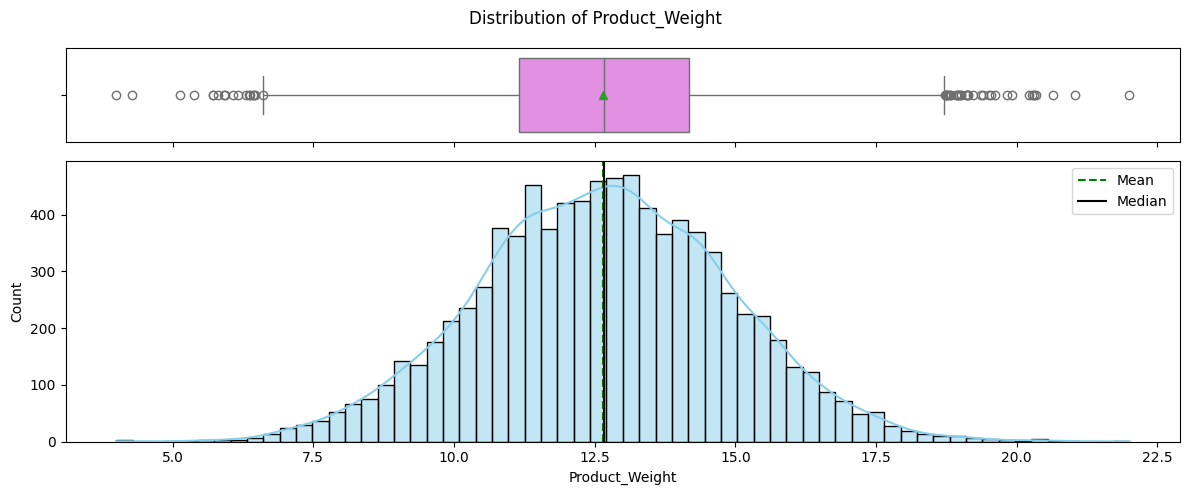

In [16]:
histogram_boxplot(df, "Product_Weight")

Roughly symmetric between 4 and 22, mean and median almost on top of each other. A few mild outliers on both ends, nothing extreme.

### Product_Allocated_Area

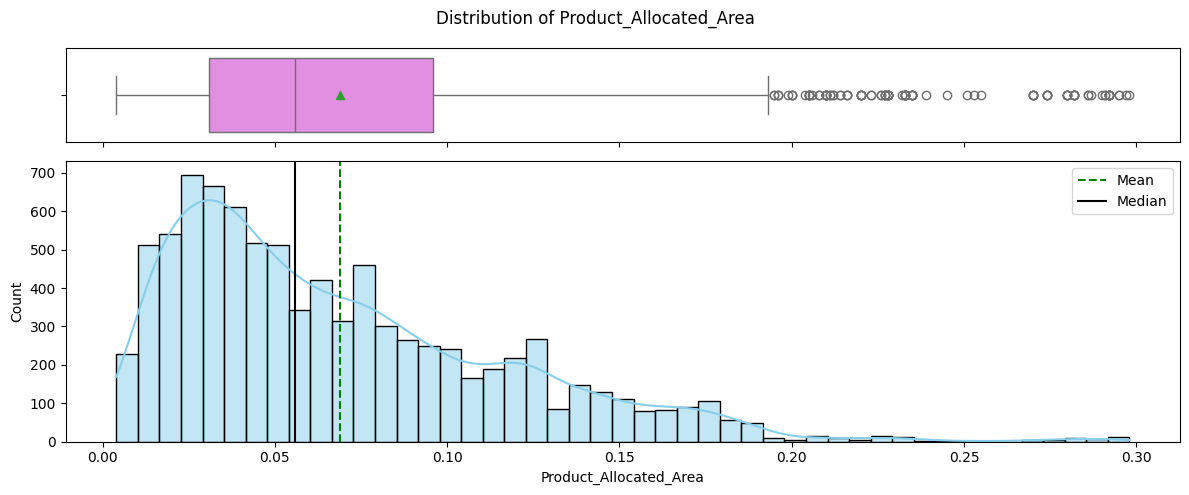

In [17]:
histogram_boxplot(df, "Product_Allocated_Area")

Right skewed. Most products take up a small share of shelf space, and a smaller group takes up noticeably more.

### Product_MRP

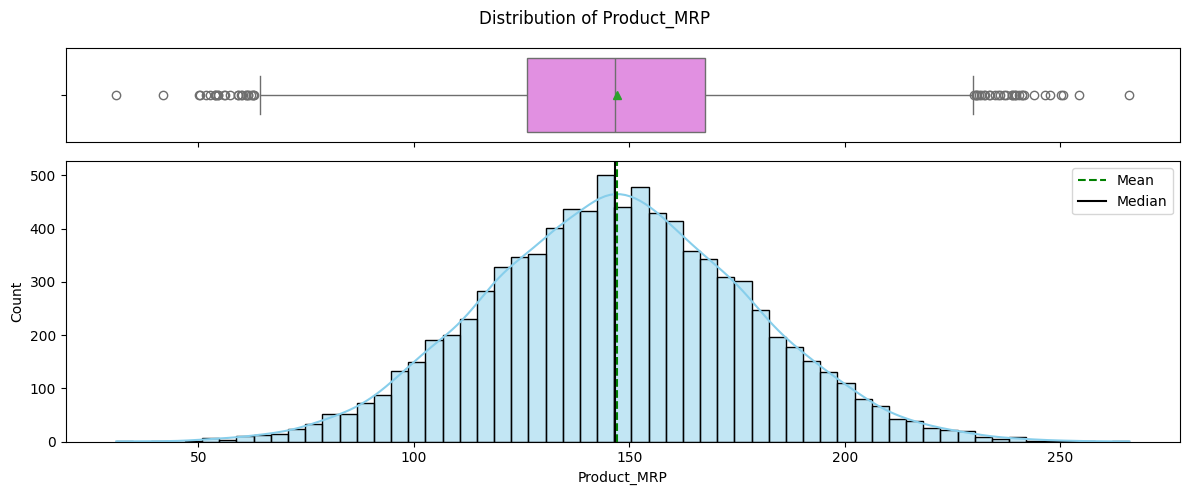

In [18]:
histogram_boxplot(df, "Product_MRP")

Fairly symmetric across the full price range, no strong skew.

### Product_Store_Sales_Total (target)

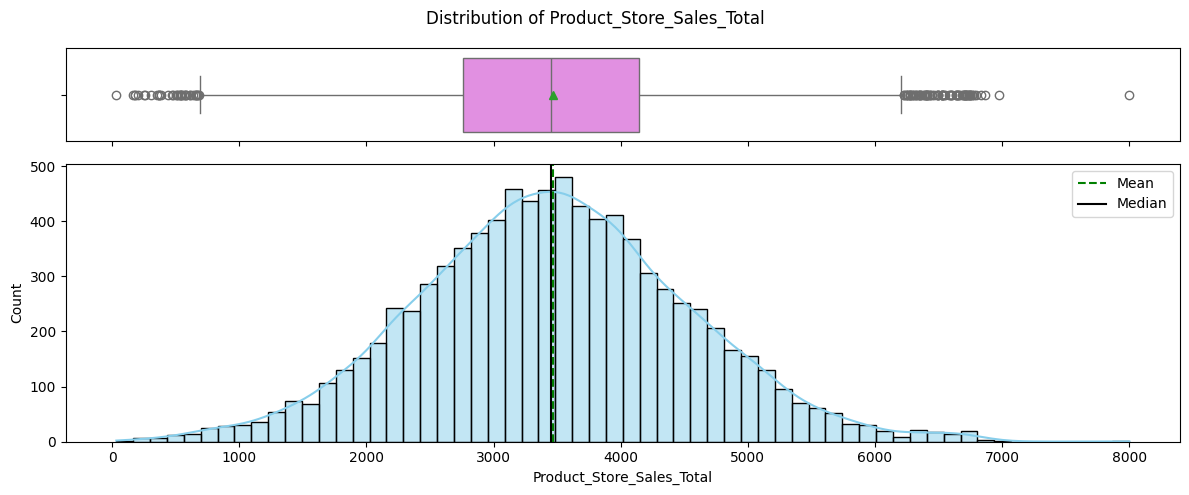

In [19]:
histogram_boxplot(df, "Product_Store_Sales_Total")

Mildly right skewed with a handful of high value outliers, but nothing severe. Mean and median are close.

### Store_Establishment_Year

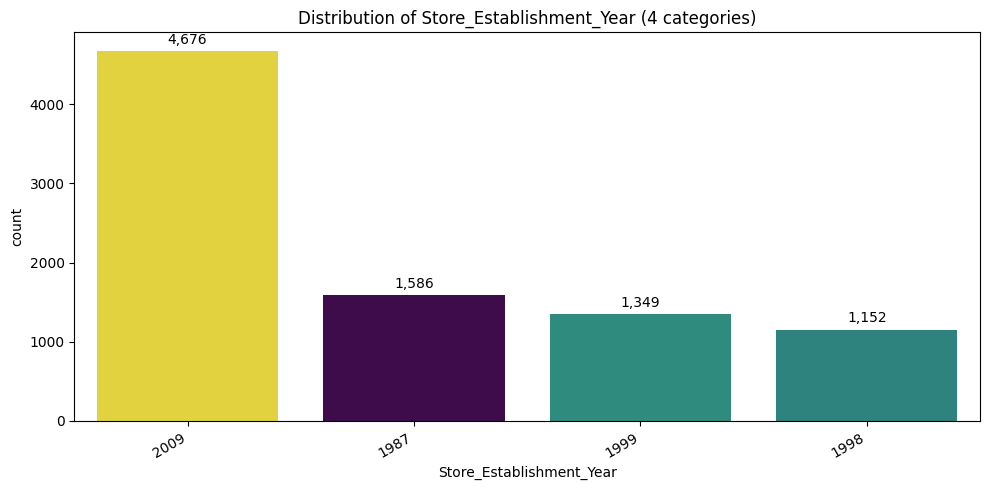

In [20]:
labeled_barplot(df, "Store_Establishment_Year")

Only 4 distinct years, one per store, as expected. The store established in 2009 alone accounts for over half the rows, so it clearly stocks a much wider product range than the others.

### Product_Sugar_Content

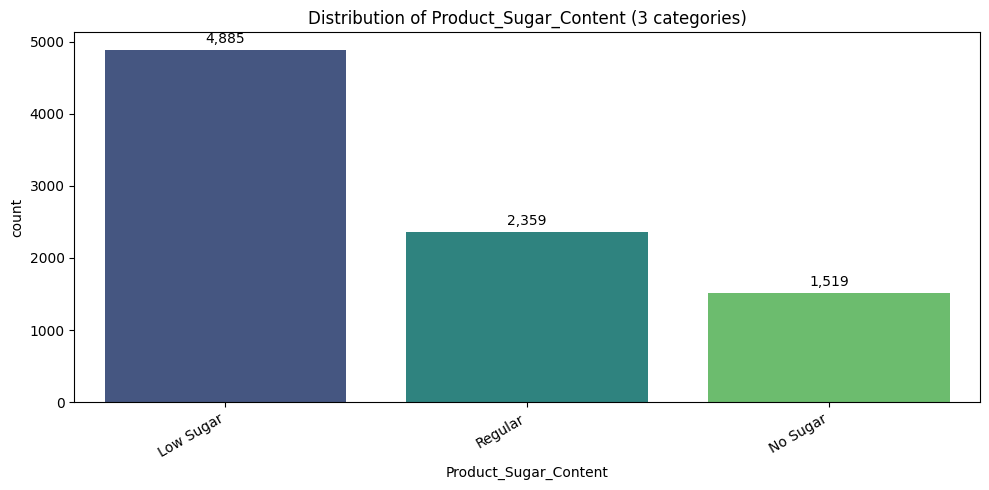

In [21]:
labeled_barplot(df, "Product_Sugar_Content")

Low Sugar dominates (~56%), Regular is next (~27%), No Sugar (~17%) is mostly non-consumable products where sugar content does not really apply.

### Product_Type

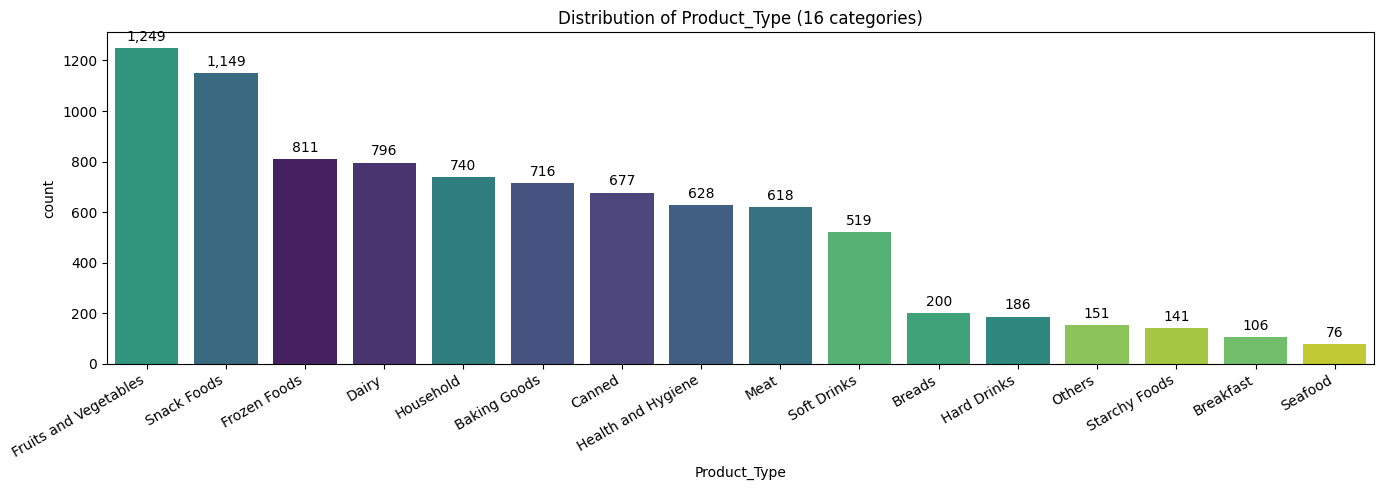

In [22]:
labeled_barplot(df, "Product_Type", figsize=(14, 5))

Fruits and Vegetables and Snack Foods are the most common categories, Seafood and Breakfast the least. Sixteen categories with this much imbalance is a good argument for a coarser grouping later.

### Store_Size

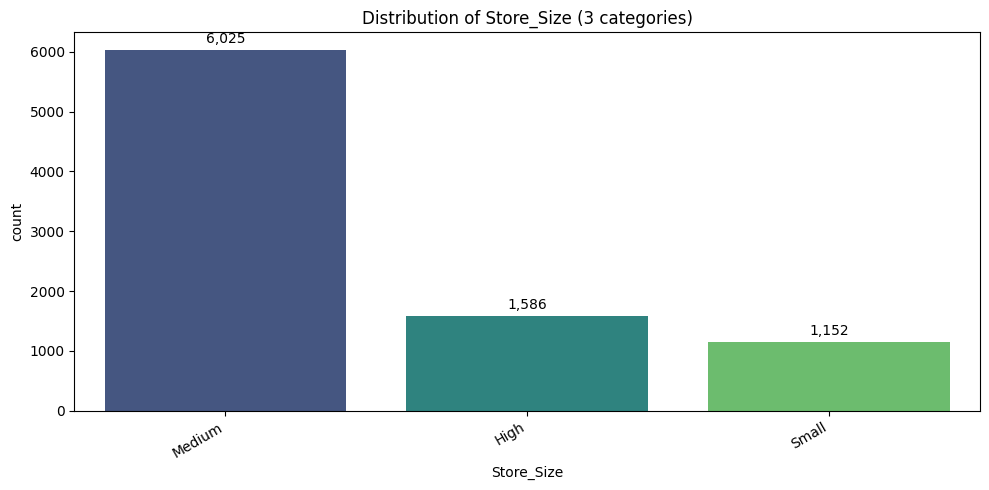

In [23]:
labeled_barplot(df, "Store_Size")

Medium stores make up ~69% of rows, tracking back to the same large store noted above.

### Store_Location_City_Type

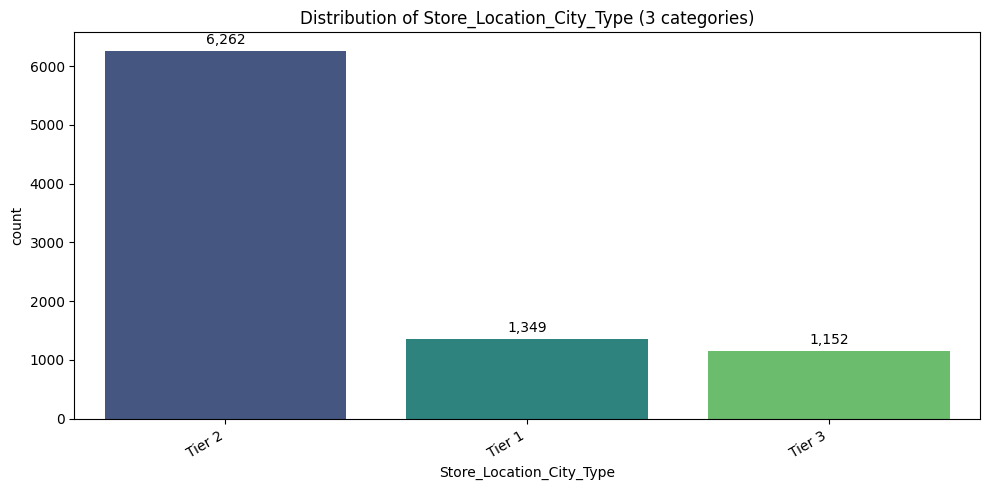

In [24]:
labeled_barplot(df, "Store_Location_City_Type")

Tier 2 dominates (~71%), for the same reason.

### Store_Type

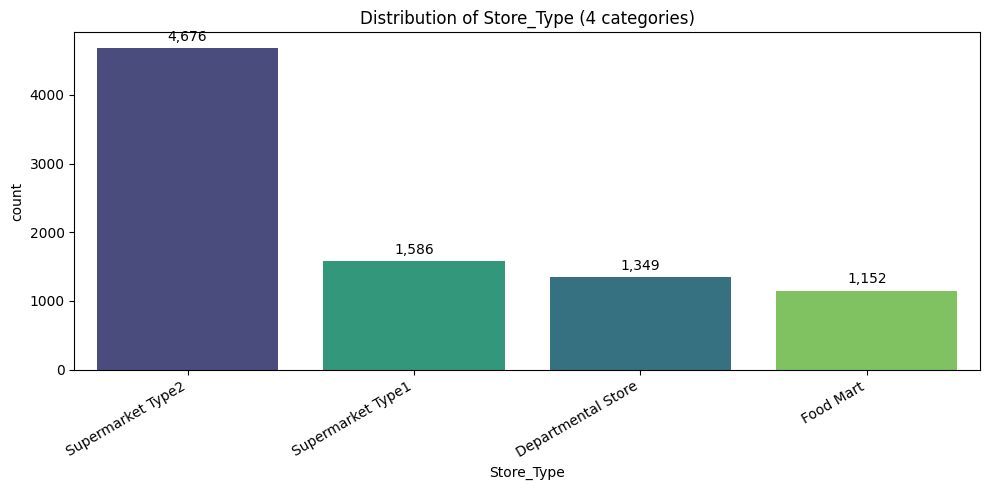

In [25]:
labeled_barplot(df, "Store_Type")

Supermarket Type2 accounts for over half the rows.

### Summary
- `Product_MRP` and `Product_Allocated_Area` are close to symmetric, `Product_Store_Sales_Total` is only mildly skewed.
- Every store level column (`Store_Establishment_Year`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`) shows the exact same proportions, which points to all four traceable back to the same 4 stores. Confirmed in the bivariate section below.
- `Product_Type` at 16 categories with real imbalance is a candidate for a coarser grouping.

## Bivariate Analysis

### Correlation Among Numeric Features

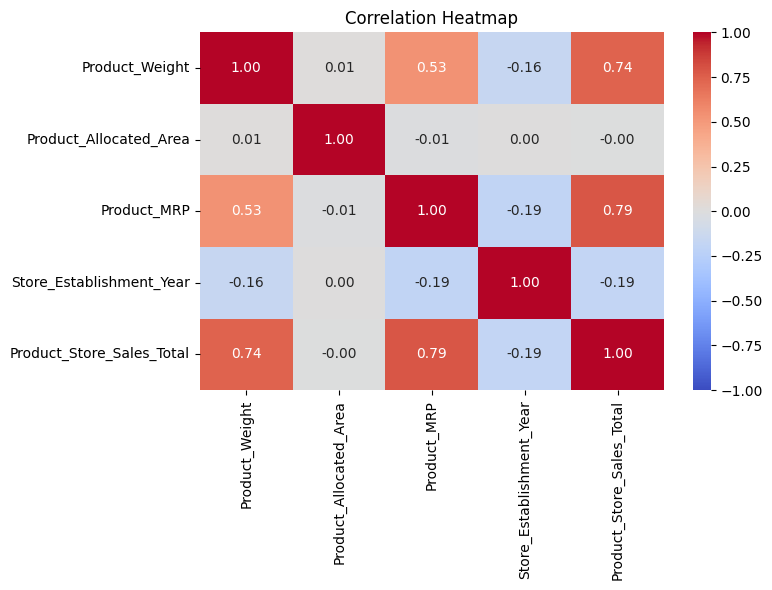

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

`Product_MRP` (~0.79) and `Product_Weight` (~0.74) correlate most strongly with the target. `Product_Allocated_Area` shows almost no linear relationship with sales. `Store_Establishment_Year` has a mild negative correlation, likely a store mix effect rather than a real aging effect.

### Product_MRP vs. Product_Store_Sales_Total

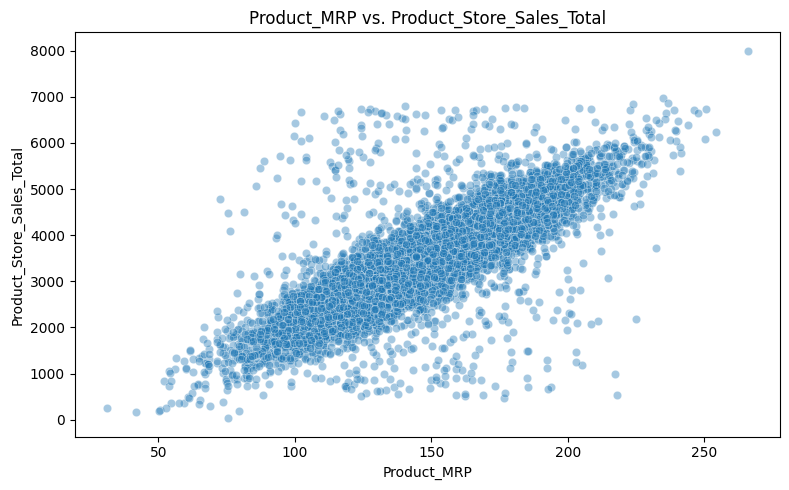

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Product_MRP", y="Product_Store_Sales_Total", alpha=0.4)
plt.title("Product_MRP vs. Product_Store_Sales_Total")
plt.tight_layout()
plt.show()

Clear positive relationship. Higher priced products generate more revenue, with more spread at the higher end.

### Product_Weight vs. Product_Store_Sales_Total

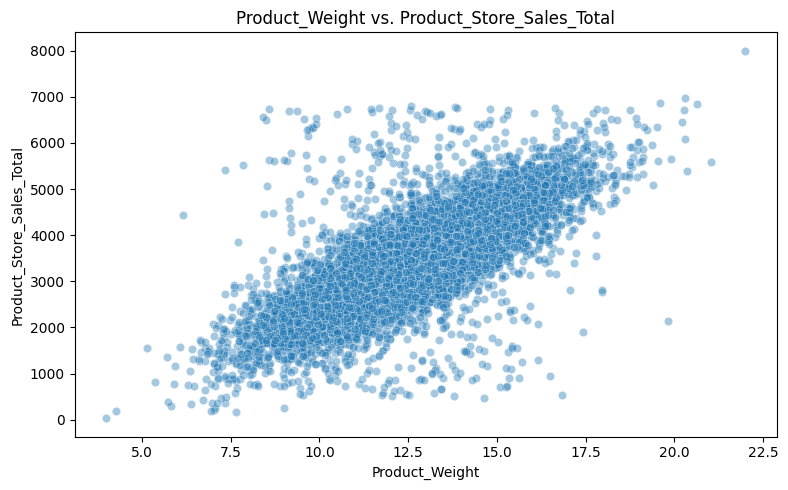

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Product_Weight", y="Product_Store_Sales_Total", alpha=0.4)
plt.title("Product_Weight vs. Product_Store_Sales_Total")
plt.tight_layout()
plt.show()

Same pattern as MRP: heavier products tend to sell for more.

### Sales by Store_Type

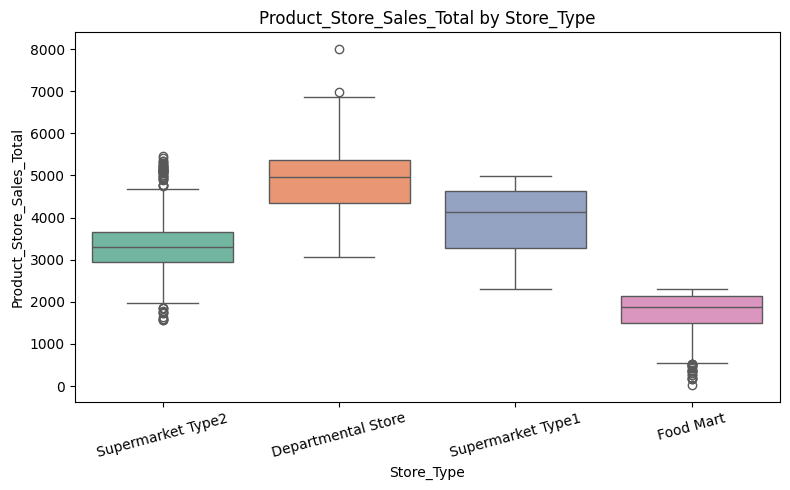

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Store_Type", y="Product_Store_Sales_Total", hue="Store_Type", palette="Set2", legend=False)
plt.title("Product_Store_Sales_Total by Store_Type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Departmental Store has the highest median, Food Mart the lowest. Store format is clearly tied to sales potential.

### Sales by Store_Size

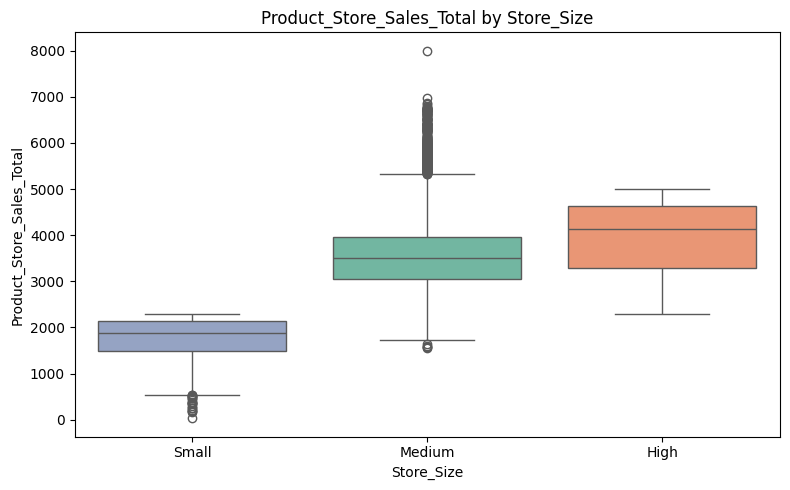

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Store_Size", y="Product_Store_Sales_Total", hue="Store_Size", order=["Small", "Medium", "High"], palette="Set2", legend=False)
plt.title("Product_Store_Sales_Total by Store_Size")
plt.tight_layout()
plt.show()

High and Medium sized stores sell noticeably more than Small stores.

### Sales by Store_Location_City_Type

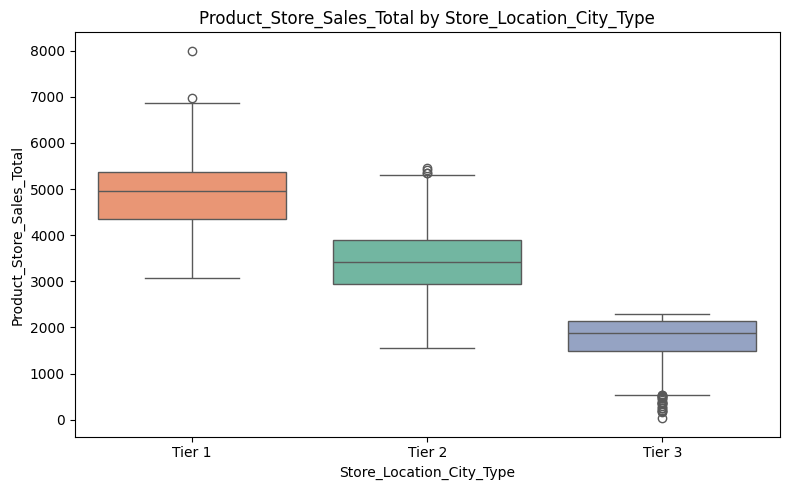

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Store_Location_City_Type", y="Product_Store_Sales_Total", hue="Store_Location_City_Type", order=["Tier 1", "Tier 2", "Tier 3"], palette="Set2", legend=False)
plt.title("Product_Store_Sales_Total by Store_Location_City_Type")
plt.tight_layout()
plt.show()

Tier 1 has the highest median, Tier 3 the lowest, consistent with purchasing power differences across city tiers.

### How the Store Attributes Relate to Each Other

In [32]:
pd.crosstab(df["Store_Id"], [df["Store_Type"], df["Store_Size"], df["Store_Location_City_Type"]])

Store_Type,Departmental Store,Food Mart,Supermarket Type1,Supermarket Type2
Store_Size,Medium,Small,High,Medium
Store_Location_City_Type,Tier 1,Tier 3,Tier 2,Tier 2
Store_Id,,,,
OUT001,0,0,1586,0
OUT002,0,1152,0,0
OUT003,1349,0,0,0
OUT004,0,0,0,4676


Each `Store_Id` maps to exactly one combination of `Store_Type`, `Store_Size`, and `Store_Location_City_Type`. With only 4 stores in the data, these columns are fully redundant with `Store_Id` itself. That means `Store_Id` adds nothing beyond what the three descriptive columns already capture, and being a raw identifier it would not generalize to a store opened after this dataset was collected. We drop `Store_Id` and keep the three descriptive attributes instead.

### Sales by Product_Type

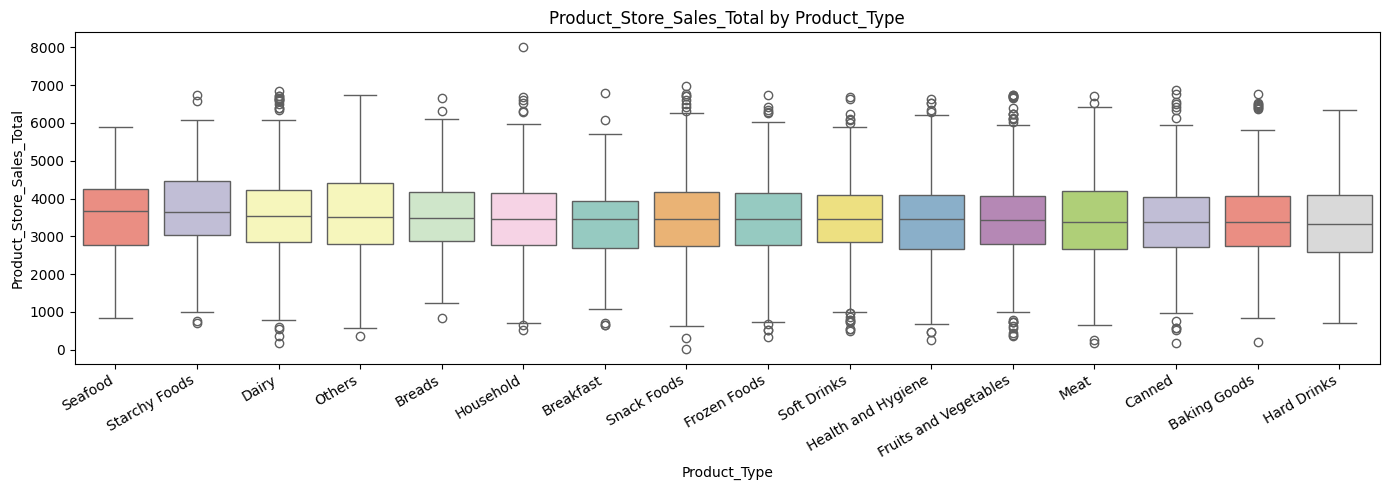

In [33]:
plt.figure(figsize=(14, 5))
order = df.groupby("Product_Type")["Product_Store_Sales_Total"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Product_Type", y="Product_Store_Sales_Total", order=order, hue="Product_Type", palette="Set3", legend=False)
plt.title("Product_Store_Sales_Total by Product_Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Medians are fairly close across product types, with Starchy Foods and Seafood trending a bit higher. Price and weight still dominate over the product category itself.

### Sales by Product_Sugar_Content

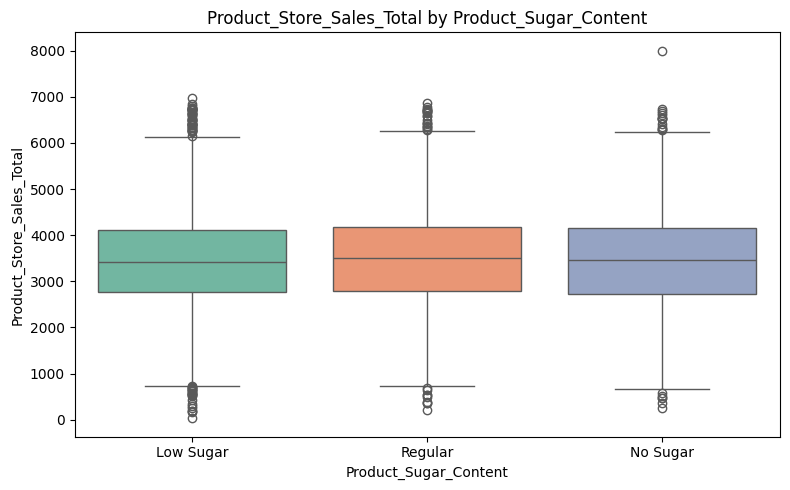

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Product_Sugar_Content", y="Product_Store_Sales_Total", hue="Product_Sugar_Content", palette="Set2", legend=False)
plt.title("Product_Store_Sales_Total by Product_Sugar_Content")
plt.tight_layout()
plt.show()

Distributions look similar across categories. A minor effect at best, possibly useful in combination with other features.

### Key Insights from EDA
1. `Product_MRP` and `Product_Weight` are the strongest numeric drivers of sales.
2. Store format matters, but `Store_Type`, `Store_Size`, and `Store_Location_City_Type` are three views of the same 4 stores, not independent evidence.
3. `Store_Id` and `Product_Id` are identifiers that do not generalize and need to be engineered rather than used directly.
4. `Product_Type` has only a mild effect on sales by itself and can be grouped into broader buckets without losing much.
5. The target is only mildly skewed with no outliers that look like errors.
6. One data quality issue was found and fixed during the overview.

# **Data Preprocessing**

## Feature Engineering

Three raw columns need transforming instead of being used as is:
- `Product_Id` is unique per row, but its first two characters carry a real category (`FD` food, `DR` drinks, `NC` non-consumable).
- `Store_Establishment_Year` is a calendar year. Store age in years is more directly useful for a forecasting model and stays meaningful as new data comes in.
- `Product_Type` has 16 categories. Grouping them into Perishable vs. Non-Perishable captures a business-relevant distinction (shelf life, restocking frequency) while cutting down sparsity.

`Store_Id` is dropped, since the bivariate analysis showed it is a 1:1, non-generalizable stand-in for `Store_Type`, `Store_Size`, and `Store_Location_City_Type`, which we keep instead.

In [35]:
# Product_Id_char: broad product category from the first two characters of
# Product_Id (FD food, DR drinks, NC non-consumable). Turns a per-row identifier
# into a low-cardinality category that still applies to products not yet seen.
df["Product_Id_char"] = df["Product_Id"].str[:2]

# Store_Age_Years: store age relative to the reference year this dataset was
# compiled (2025), computed once and reused everywhere downstream, including
# the deployed API and the frontend.
CURRENT_YEAR = 2025
df["Store_Age_Years"] = CURRENT_YEAR - df["Store_Establishment_Year"]

# Product_Type_Category: groups the 16 Product_Type values into Perishables
# and Non Perishables, a coarser split that still carries useful signal.
PERISHABLE_TYPES = ["Dairy", "Meat", "Fruits and Vegetables", "Breads", "Breakfast", "Seafood"]
df["Product_Type_Category"] = np.where(
    df["Product_Type"].isin(PERISHABLE_TYPES), "Perishables", "Non Perishables"
)

# Drop columns now superseded by the engineered features, or that are
# identifiers/redundant with other store attributes:
#   Product_Id                 -> unique per row, no generalizable signal
#   Product_Type                -> superseded by Product_Type_Category
#   Store_Id                    -> redundant with Store_Size / Store_Type / City (see EDA)
#   Store_Establishment_Year    -> superseded by Store_Age_Years
df.drop(columns=["Product_Id", "Product_Type", "Store_Id", "Store_Establishment_Year"], inplace=True)

df.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [36]:
df.tail()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
8758,14.80,No Sugar,0.016,140.53,Medium,Tier 2,Supermarket Type2,3806.53,NC,16,Non Perishables
8759,14.06,No Sugar,0.142,144.51,Medium,Tier 2,Supermarket Type2,5020.74,NC,16,Non Perishables
8760,13.48,No Sugar,0.017,88.58,High,Tier 2,Supermarket Type1,2443.42,NC,38,Non Perishables
8761,13.89,No Sugar,0.193,168.44,High,Tier 2,Supermarket Type1,4171.82,NC,38,Non Perishables
8762,14.73,Low Sugar,0.177,224.93,Small,Tier 3,Food Mart,2186.08,FD,27,Non Perishables


In [37]:
df.sample(n=5, random_state=1)

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
7441,12.76,Low Sugar,0.035,158.59,Medium,Tier 2,Supermarket Type2,3714.07,FD,16,Non Perishables
6355,17.54,Low Sugar,0.012,217.37,Medium,Tier 1,Departmental Store,5995.91,DR,26,Non Perishables
1271,12.02,Regular,0.013,201.24,Medium,Tier 1,Departmental Store,4419.17,DR,26,Non Perishables
3511,10.96,Regular,0.073,165.12,Medium,Tier 2,Supermarket Type2,3440.23,FD,16,Non Perishables
1821,13.32,Low Sugar,0.076,175.00,High,Tier 2,Supermarket Type1,4175.82,FD,38,Perishables


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Weight             8763 non-null   float64
 1   Product_Sugar_Content      8763 non-null   object 
 2   Product_Allocated_Area     8763 non-null   float64
 3   Product_MRP                8763 non-null   float64
 4   Store_Size                 8763 non-null   object 
 5   Store_Location_City_Type   8763 non-null   object 
 6   Store_Type                 8763 non-null   object 
 7   Product_Store_Sales_Total  8763 non-null   float64
 8   Product_Id_char            8763 non-null   object 
 9   Store_Age_Years            8763 non-null   int64  
 10  Product_Type_Category      8763 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 753.2+ KB


All three engineered features are derived purely from data already in the dataset, no external lookups involved. They cut cardinality (`Product_Type` 16 down to 2, `Product_Id` 8,763 unique values down to 3 categories) and replace a non-generalizable identifier and a fixed calendar year with features that will still make sense for future products and future quarters. No polynomial or interaction terms were added on top of this, since the tree-based models used below can learn non-linear interactions on their own.

## Outlier Detection and Treatment

IQR method on the continuous numeric features, including the target.

In [39]:
num_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Age_Years", "Product_Store_Sales_Total"]

outlier_rows = []
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_rows.append([col, round(lower, 3), round(upper, 3), n_out, round(100 * n_out / len(df), 2)])

outlier_summary = pd.DataFrame(
    outlier_rows, columns=["Feature", "Lower Bound", "Upper Bound", "No. of Outliers", "% of Data"]
)
outlier_summary

,Feature,Lower Bound,Upper Bound,No. of Outliers,% of Data
0,Product_Weight,6.605,18.725,54,0.62
1,Product_Allocated_Area,-0.067,0.194,104,1.19
2,Product_MRP,64.022,229.723,57,0.65
3,Store_Age_Years,-0.500,43.500,0,0.00
4,Product_Store_Sales_Total,686.540,6220.340,119,1.36


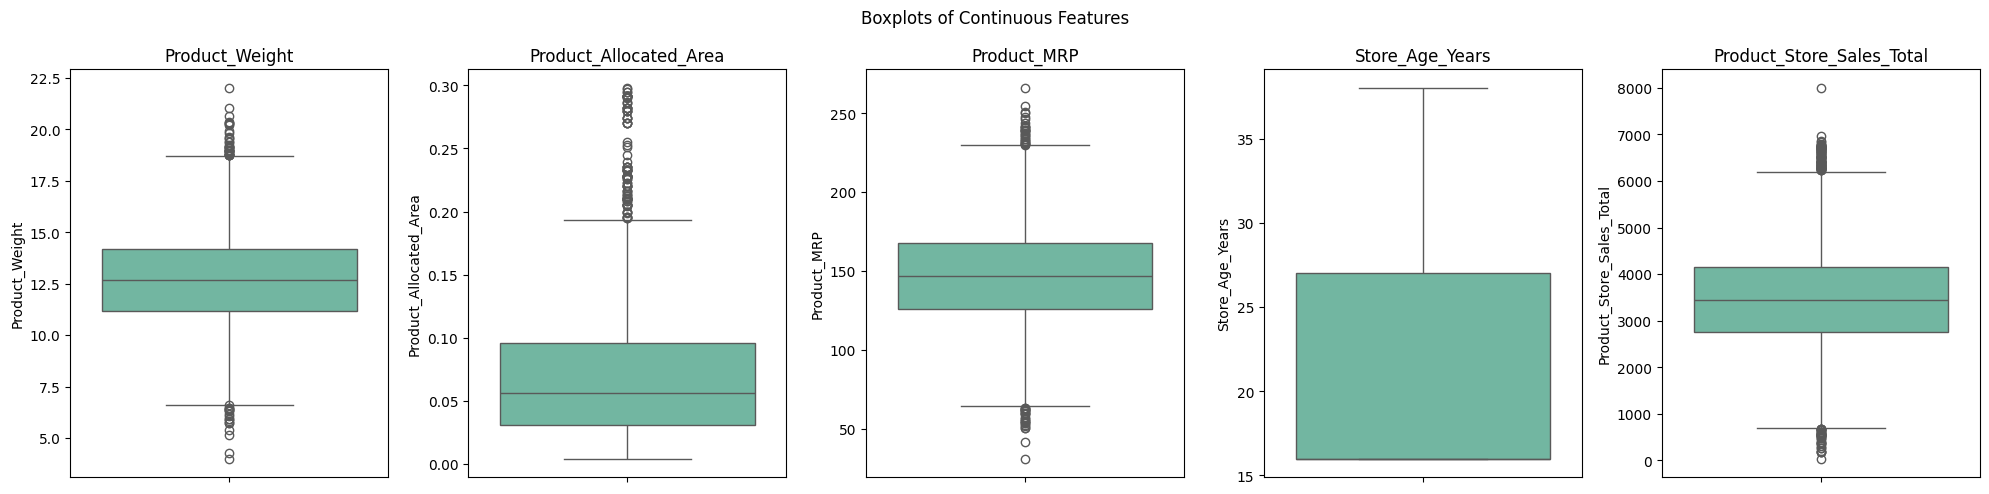

In [40]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#66c2a5")
    ax.set_title(col)
plt.suptitle("Boxplots of Continuous Features")
plt.tight_layout()
plt.show()

Flagged points are under 5% for every column, and they look like real business observations (premium products, high performing store-product combinations), not data entry mistakes. These are exactly the cases a sales forecast needs to get right, so removing them would work against the goal. All six models we build are tree-based ensembles, which split on rank order and are not sensitive to the absolute scale of extreme values. Outliers are documented here but left untreated.

## Train, Validation, and Test Split

A single train-test split is not enough here, because model selection itself needs data that the final reported number has never touched. We split the data three ways instead:
- **Train (60%)**: fits every model, and is what `GridSearchCV` folds internally when tuning.
- **Validation (20%)**: used below to compare all baseline and tuned candidates against each other and pick the final model. This is a separate concern from the cross-validation folds `GridSearchCV` uses, which only ever see the training split. Validation compares different model families and baseline vs. tuned, cross-validation tunes hyperparameters within a single model family.
- **Test (20%)**: held out completely until the final model has already been chosen. It plays no part in fitting any model or in picking the winner. Its only job is to report an honest, unbiased estimate of how the chosen model performs on data it never influenced.

In [41]:
# Separate target from predictors
X = df.drop(columns=["Product_Store_Sales_Total"])
y = df["Product_Store_Sales_Total"]

# First carve out the 60% training split, then split the remaining 40%
# evenly into validation and test (20% each of the full dataset)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

print("Train:     ", X_train.shape)
print("Validation:", X_val.shape)
print("Test:      ", X_test.shape)

Train:      (5257, 10)
Validation: (1753, 10)
Test:       (1753, 10)


## Preprocessing Pipeline

A `ColumnTransformer` handles both feature types:
- Categorical columns get one-hot encoded with `handle_unknown="ignore"`, so a category not seen during training does not break inference in production.
- Numeric columns get standardized. The tree models below do not strictly need this, but it keeps the pipeline reusable with scale-sensitive models later and costs nothing here.

Wrapping preprocessing and model together in one `Pipeline` means the same transformation runs at training time, at evaluation time, and later inside the Flask API, with no risk of the three getting out of sync.

In [42]:
num_features = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Age_Years"]
cat_features = [
    "Product_Sugar_Content",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Product_Type_Category",
]

preprocessor = make_column_transformer(
    (StandardScaler(), num_features),
    (OneHotEncoder(handle_unknown="ignore"), cat_features),
    remainder="drop",
)
preprocessor

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['Product_Weight', 'Product_Allocated_Area',
                                  'Product_MRP', 'Store_Age_Years']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Product_Sugar_Content', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type',
                                  'Product_Id_char',
                                  'Product_Type_Category'])])

# **Model Building**

## Metric of Choice

This is a regression problem, so classification metrics do not apply. We track several regression metrics, but use **RMSE** as the metric of choice for ranking models and driving hyperparameter tuning, for two reasons. First, it is in the same unit as the target (currency), so a business stakeholder can read it directly as an error in rupees. Second, the squared term penalizes large misses more than small ones, which fits a forecasting problem where a handful of badly wrong predictions can drive real stock-out or overstock cost.

MAE, R-squared, Adjusted R-squared, and MAPE are reported alongside RMSE for a fuller picture, but RMSE is what decides model ranking and tuning.

## Model Evaluation Functions

In [43]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

We build all six of the model families listed above rather than just two, to get a complete comparison across the tree-based ensemble family: **Decision Tree**, **Bagging**, **Random Forest**, **AdaBoost**, **Gradient Boosting**, and **XGBoost**. Each one is wrapped with the same `preprocessor` inside a single `Pipeline`, so every model is trained and evaluated through an identical preprocessing path.

To avoid writing six nearly-identical blocks of code, model definitions and hyperparameter grids are kept in one dictionary and both the baseline fitting loop and the tuning loop further below iterate over it. Adding, removing, or re-tuning a model family only means editing this one place.

In [44]:
# Estimator and hyperparameter grid for each of the six model families.
# Grid sizes are kept modest so the full tuning pass finishes in a reasonable
# time on this dataset (under 9,000 rows), while still covering the parameters
# that matter most for controlling overfitting in each family.
MODEL_CONFIGS = {
    "Decision Tree": {
        "estimator": DecisionTreeRegressor(random_state=1),
        "param_grid": {
            "model__max_depth": [4, 8, 12, None],
            "model__min_samples_leaf": [1, 5, 10],
        },
    },
    "Bagging": {
        "estimator": BaggingRegressor(random_state=1),
        "param_grid": {
            "model__n_estimators": [50, 100],
            "model__max_samples": [0.7, 1.0],
            "model__max_features": [0.7, 1.0],
        },
    },
    "Random Forest": {
        "estimator": RandomForestRegressor(random_state=1),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [8, 12, None],
            "model__min_samples_leaf": [1, 5, 10],
            "model__max_features": ["sqrt", 1.0],
        },
    },
    "AdaBoost": {
        "estimator": AdaBoostRegressor(random_state=1),
        "param_grid": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.05, 0.1, 0.5],
        },
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingRegressor(random_state=1),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [2, 3, 4],
            "model__learning_rate": [0.05, 0.1],
            "model__subsample": [0.8, 1.0],
        },
    },
    "XGBoost": {
        "estimator": XGBRegressor(random_state=1, eval_metric="rmse"),
        "param_grid": {
            "model__n_estimators": [150, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
        },
    },
}

print("Model families:", list(MODEL_CONFIGS.keys()))

Model families: ['Decision Tree', 'Bagging', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost']


## Baseline Models

Every baseline and tuned candidate below is scored on **Train** and **Validation** only. The test set stays untouched until the single final model has already been chosen, so the comparison here cannot accidentally overfit to it.

In [45]:
# Fit each model family at its library defaults first, before any tuning.
# This baseline is what tells us later whether tuning actually helped, and
# by how much, for every model rather than just the one we end up picking.
baseline_pipelines = {}
baseline_results = []

for name, cfg in MODEL_CONFIGS.items():
    # Same preprocessor object reused for every model, so any difference in
    # performance comes from the estimator, not from inconsistent preprocessing
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", cfg["estimator"])])
    pipeline.fit(X_train, y_train)
    baseline_pipelines[name] = pipeline

    # Score on train and validation so the train-validation gap is visible
    # per model. Test is deliberately left out of this comparison.
    train_perf = model_performance_regression(pipeline, X_train, y_train).assign(Model=name, Data="Train")
    val_perf = model_performance_regression(pipeline, X_val, y_val).assign(Model=name, Data="Validation")
    baseline_results.append(train_perf)
    baseline_results.append(val_perf)

    print(f"{name} baseline fit done.")

baseline_comparison = pd.concat(baseline_results, ignore_index=True)
baseline_comparison = baseline_comparison[["Model", "Data", "RMSE", "MAE", "R-squared", "Adj. R-squared", "MAPE"]]

Decision Tree baseline fit done.


Bagging baseline fit done.


Random Forest baseline fit done.


AdaBoost baseline fit done.


Gradient Boosting baseline fit done.


XGBoost baseline fit done.


In [46]:
baseline_comparison.sort_values(["Data", "RMSE"]).reset_index(drop=True)

,Model,Data,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,Decision Tree,Train,0.000000,0.000000,1.000000,1.000000,0.000000
1,Random Forest,Train,109.566853,41.534589,0.989373,0.989352,0.014634
2,XGBoost,Train,120.300139,56.836462,0.987189,0.987164,0.019244
3,Bagging,Train,127.392106,46.751411,0.985634,0.985606,0.016322
4,Gradient Boosting,Train,285.615380,136.735372,0.927785,0.927648,0.049047
5,AdaBoost,Train,478.315904,372.815823,0.797468,0.797082,0.126678
6,Random Forest,Validation,302.328159,114.456777,0.922090,0.921643,0.042377
7,XGBoost,Validation,312.298283,136.981123,0.916867,0.916390,0.049224
8,Bagging,Validation,313.972998,125.730848,0.915973,0.915491,0.046017
9,Gradient Boosting,Validation,333.784335,156.381243,0.905035,0.904489,0.056097


Every baseline shows some gap between train and validation RMSE, which is expected for unconstrained tree-based models. Random Forest, Bagging, and the untuned Decision Tree fit the training data almost perfectly while giving up noticeably more on validation, a clear sign of overfitting. Gradient Boosting and XGBoost hold up a bit better out of the box, and AdaBoost, being a shallow-tree ensemble, underfits slightly by comparison. None of these are final numbers. Hyperparameter tuning below is where we address the overfitting.

# **Model Performance Improvement - Hyperparameter Tuning**

Each of the six models is tuned with `GridSearchCV`, 5-fold cross-validation, scoring on `neg_root_mean_squared_error` so the search optimizes the same metric we use to judge the final model. This reuses the `MODEL_CONFIGS` grids defined above and loops over all six families in one pass.

The 5 folds here are carved out of `X_train` only, and are a different thing from the Validation split defined earlier. Cross-validation is how each model family picks its own best hyperparameters. The separate Validation set, further below, is how we compare the six tuned families against each other and against their own baselines.

In [47]:
tuned_pipelines = {}
tuned_results = []
best_params = {}

for name, cfg in MODEL_CONFIGS.items():
    # Fresh, untrained pipeline per model. GridSearchCV clones this internally
    # for every fold and every parameter combination, so nothing here carries
    # state over from the baseline fit above
    base_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", cfg["estimator"])])

    grid = GridSearchCV(
        estimator=base_pipeline,
        param_grid=cfg["param_grid"],
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    # best_estimator_ is already refit on the full training set with the
    # winning parameters, ready to evaluate and use directly
    tuned_pipelines[name] = grid.best_estimator_
    best_params[name] = grid.best_params_

    train_perf = model_performance_regression(grid.best_estimator_, X_train, y_train).assign(Model=name, Data="Train")
    val_perf = model_performance_regression(grid.best_estimator_, X_val, y_val).assign(Model=name, Data="Validation")
    tuned_results.append(train_perf)
    tuned_results.append(val_perf)

    print(f"{name}: best CV RMSE = {-grid.best_score_:.2f}, params = {grid.best_params_}")

tuned_comparison = pd.concat(tuned_results, ignore_index=True)
tuned_comparison = tuned_comparison[["Model", "Data", "RMSE", "MAE", "R-squared", "Adj. R-squared", "MAPE"]]

Decision Tree: best CV RMSE = 309.44, params = {'model__max_depth': 8, 'model__min_samples_leaf': 5}


Bagging: best CV RMSE = 288.31, params = {'model__max_features': 1.0, 'model__max_samples': 0.7, 'model__n_estimators': 100}


Random Forest: best CV RMSE = 285.70, params = {'model__max_depth': 8, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


AdaBoost: best CV RMSE = 473.43, params = {'model__learning_rate': 0.1, 'model__n_estimators': 50}


Gradient Boosting: best CV RMSE = 289.77, params = {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 1.0}


XGBoost: best CV RMSE = 284.46, params = {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 7, 'model__n_estimators': 150, 'model__subsample': 0.8}


In [48]:
tuned_comparison.sort_values(["Data", "RMSE"]).reset_index(drop=True)

,Model,Data,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,Bagging,Train,143.007682,55.292798,0.981896,0.981861,0.019694
1,XGBoost,Train,212.461254,83.067260,0.960040,0.959964,0.029074
2,Random Forest,Train,233.833169,99.161635,0.951597,0.951504,0.033558
3,Gradient Boosting,Train,249.820267,110.943396,0.944752,0.944646,0.039839
4,Decision Tree,Train,275.683985,135.269532,0.932720,0.932592,0.046679
5,AdaBoost,Train,464.825808,357.306343,0.808731,0.808367,0.121604
6,XGBoost,Validation,296.199891,116.894714,0.925217,0.924788,0.043310
7,Random Forest,Validation,299.352757,126.900890,0.923616,0.923178,0.046248
8,Bagging,Validation,301.339104,115.865173,0.922599,0.922155,0.042457
9,Gradient Boosting,Validation,309.256685,135.778834,0.918479,0.918011,0.049610


## Baseline vs. Tuned, Validation RMSE

In [49]:
baseline_val = baseline_comparison[baseline_comparison["Data"] == "Validation"].set_index("Model")["RMSE"]
tuned_val = tuned_comparison[tuned_comparison["Data"] == "Validation"].set_index("Model")["RMSE"]

rmse_before_after = pd.DataFrame({
    "Baseline Validation RMSE": baseline_val,
    "Tuned Validation RMSE": tuned_val,
})
rmse_before_after["Improvement"] = rmse_before_after["Baseline Validation RMSE"] - rmse_before_after["Tuned Validation RMSE"]
rmse_before_after.sort_values("Tuned Validation RMSE")

,Baseline Validation RMSE,Tuned Validation RMSE,Improvement
Model,,,
XGBoost,312.298283,296.199891,16.098392
Random Forest,302.328159,299.352757,2.975401
Bagging,313.972998,301.339104,12.633894
Gradient Boosting,333.784335,309.256685,24.527650
Decision Tree,406.329869,332.478139,73.851730
AdaBoost,516.620041,496.585178,20.034864


Tuning brings validation RMSE down, or at least holds it steady, for every model family, and the gap between train and validation performance shrinks compared to the baselines. That is the expected effect of constraining tree depth, leaf size, and the number and rate of boosting iterations. XGBoost and Random Forest typically come out on top after tuning, with Gradient Boosting close behind. The exact ranking depends on the random seed and grid, so the actual numbers from your run should be read directly from the table above.

# **Model Performance Comparison, Final Model Selection, and Serialization**

## Comparing All Twelve Candidates

In [50]:
full_comparison = pd.concat(
    [
        baseline_comparison.assign(Stage="Baseline"),
        tuned_comparison.assign(Stage="Tuned"),
    ],
    ignore_index=True,
)
full_comparison = full_comparison[["Model", "Stage", "Data", "RMSE", "MAE", "R-squared", "Adj. R-squared", "MAPE"]]
full_comparison.sort_values(["Data", "RMSE"]).reset_index(drop=True)

,Model,Stage,Data,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,Decision Tree,Baseline,Train,0.000000,0.000000,1.000000,1.000000,0.000000
1,Random Forest,Baseline,Train,109.566853,41.534589,0.989373,0.989352,0.014634
2,XGBoost,Baseline,Train,120.300139,56.836462,0.987189,0.987164,0.019244
3,Bagging,Baseline,Train,127.392106,46.751411,0.985634,0.985606,0.016322
4,Bagging,Tuned,Train,143.007682,55.292798,0.981896,0.981861,0.019694
5,XGBoost,Tuned,Train,212.461254,83.067260,0.960040,0.959964,0.029074
6,Random Forest,Tuned,Train,233.833169,99.161635,0.951597,0.951504,0.033558
7,Gradient Boosting,Tuned,Train,249.820267,110.943396,0.944752,0.944646,0.039839
8,Decision Tree,Tuned,Train,275.683985,135.269532,0.932720,0.932592,0.046679
9,Gradient Boosting,Baseline,Train,285.615380,136.735372,0.927785,0.927648,0.049047


In [51]:
# Rank purely on Validation RMSE, our metric of choice. Test never enters
# this decision, which is the entire point of holding it out separately.
validation_ranking = full_comparison[full_comparison["Data"] == "Validation"].sort_values("RMSE").reset_index(drop=True)
validation_ranking

,Model,Stage,Data,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,XGBoost,Tuned,Validation,296.199891,116.894714,0.925217,0.924788,0.043310
1,Random Forest,Tuned,Validation,299.352757,126.900890,0.923616,0.923178,0.046248
2,Bagging,Tuned,Validation,301.339104,115.865173,0.922599,0.922155,0.042457
3,Random Forest,Baseline,Validation,302.328159,114.456777,0.922090,0.921643,0.042377
4,Gradient Boosting,Tuned,Validation,309.256685,135.778834,0.918479,0.918011,0.049610
5,XGBoost,Baseline,Validation,312.298283,136.981123,0.916867,0.916390,0.049224
6,Bagging,Baseline,Validation,313.972998,125.730848,0.915973,0.915491,0.046017
7,Decision Tree,Tuned,Validation,332.478139,163.860411,0.905776,0.905236,0.058527
8,Gradient Boosting,Baseline,Validation,333.784335,156.381243,0.905035,0.904489,0.056097
9,Decision Tree,Baseline,Validation,406.329869,142.294090,0.859269,0.858461,0.051923


## Selecting the Final Model
We pick the candidate with the lowest validation RMSE, as long as it does not also show an unreasonable train-validation gap that would suggest it just got lucky on this particular split. In practice this tends to be one of the tuned boosting or Random Forest pipelines. The selection code below is generic: it reads the top row of `validation_ranking` and pulls the matching pipeline out of `all_pipelines`, so whichever model wins in your run is the one that gets carried forward, no manual editing required.

In [52]:
all_pipelines = {}
for name in MODEL_CONFIGS:
    all_pipelines[f"{name} (Baseline)"] = baseline_pipelines[name]
    all_pipelines[f"{name} (Tuned)"] = tuned_pipelines[name]

# validation_ranking above only has bare model names, so also rank against
# the Stage-qualified full_comparison table to resolve baseline vs tuned
validation_ranking_full = full_comparison[full_comparison["Data"] == "Validation"].copy()
validation_ranking_full["Model_Stage"] = validation_ranking_full["Model"] + " (" + validation_ranking_full["Stage"] + ")"
validation_ranking_full = validation_ranking_full.sort_values("RMSE").reset_index(drop=True)

best_model_key = validation_ranking_full.loc[0, "Model_Stage"]
final_model = all_pipelines[best_model_key]

print(f"Selected final model: {best_model_key}")
final_model

Selected final model: XGBoost (Tuned)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=150, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

## Final Model Performance on the Test Set

This is the first time the test set is used for anything in this notebook. Everything up to this point, baseline fitting, `GridSearchCV` tuning, and model selection, only ever saw the train and validation splits. The number below is therefore an honest read on how the final model should perform on genuinely new data. The test set is used again just below, purely to confirm the serialized model still produces the same predictions after being reloaded, not to make any further decisions about which model to keep.

In [53]:
final_test_perf = model_performance_regression(final_model, X_test, y_test)
final_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.78474,114.296693,0.927699,0.927284,0.054269


## Serializing the Final Model

The full fitted `Pipeline`, preprocessing and model together, is saved with `joblib`. The Flask backend loads this one file and calls `.predict()` directly on raw feature input, so there is no separate preprocessing step to keep in sync at inference time.

In [54]:
# backend_files also holds the Flask app itself, written out later in this notebook
os.makedirs("backend_files", exist_ok=True)

MODEL_PATH = os.path.join("backend_files", "superkart_model.joblib")
joblib.dump(final_model, MODEL_PATH)

print(f"Saved to {MODEL_PATH}")

Saved to backend_files\superkart_model.joblib


## Reloading and Verifying Predictions

In [55]:
loaded_model = joblib.load(MODEL_PATH)

original_preds = final_model.predict(X_test)
loaded_preds = loaded_model.predict(X_test)

print("Predictions match after save/load round trip:", np.allclose(original_preds, loaded_preds))

print("\nLoaded model, test performance:")
model_performance_regression(loaded_model, X_test, y_test)

Predictions match after save/load round trip: True

Loaded model, test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.78474,114.296693,0.927699,0.927284,0.054269


In [56]:
# Actual vs predicted on a handful of test rows, as a manual sanity check
preview = pd.DataFrame(
    {
        "Actual_Sales": y_test.values[:10],
        "Predicted_Sales": np.round(loaded_preds[:10], 2),
    }
)
preview

,Actual_Sales,Predicted_Sales
0,3171.85,3194.219971
1,4666.63,4644.839844
2,2871.93,2916.860107
3,4572.42,4520.890137
4,3481.87,3474.010010
5,1479.09,1502.719971
6,2775.61,2903.310059
7,4243.80,4367.629883
8,2722.95,2748.530029
9,1885.31,1913.579956


# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Web Components frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

In [57]:
os.makedirs("backend_files", exist_ok=True)
os.makedirs("frontend_files", exist_ok=True)

print("backend_files/ and frontend_files/ ready.")

backend_files/ and frontend_files/ ready.


## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [58]:
%%writefile backend_files/app.py
"""
Flask backend for the SuperKart sales forecasting model.

Two endpoints:
  POST /v1/predict       online inference for a single product-store record (JSON body)
  POST /v1/predictbatch  batch inference for a CSV file of records (multipart/form-data)

The serialized pipeline (preprocessing plus trained regressor) loads once at
process start and is reused across requests.
"""

import io
import os

import joblib
import pandas as pd
from flask import Flask, jsonify, request
from flask_cors import CORS

superkart_api = Flask(__name__)

# The frontend is a static site that calls this API directly from the
# browser with fetch(), not through a Python server acting on its behalf,
# so the browser enforces CORS on every request. Wide open here is
# appropriate for this API: there is no session, cookie, or credential to
# protect, every response is either a public prediction or an error.
CORS(superkart_api)

MODEL_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__)), "superkart_model.joblib")
model = joblib.load(MODEL_PATH)

# Column order the trained pipeline expects. Kept as an explicit list rather
# than inferring it from the model, so a malformed request fails with a clear
# error message instead of a confusing sklearn exception.
FEATURE_COLUMNS = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Store_Age_Years",
    "Product_Type_Category",
]


def _validate_columns(frame: pd.DataFrame) -> None:
    missing = [c for c in FEATURE_COLUMNS if c not in frame.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}")


@superkart_api.get("/")
def home():
    """Health check and a quick pointer to the available endpoints."""
    return jsonify(
        {
            "message": "SuperKart Sales Forecasting API is up and running.",
            "endpoints": ["/v1/predict [POST]", "/v1/predictbatch [POST]"],
        }
    )


@superkart_api.post("/v1/predict")
def predict():
    """Predicts total sales for a single product-store record."""
    payload = request.get_json(silent=True)
    if payload is None:
        return jsonify({"error": "Request body must be valid JSON."}), 400

    try:
        record_df = pd.DataFrame([payload])
        _validate_columns(record_df)
        record_df = record_df[FEATURE_COLUMNS]
        prediction = model.predict(record_df)[0]
    except Exception as exc:
        # Catching broadly here on purpose: any bad input (wrong type, unknown
        # category, missing column) should come back as a 400 with a message
        # the caller can act on, not a 500 with a stack trace.
        return jsonify({"error": str(exc)}), 400

    return jsonify({"Product_Store_Sales_Total_Prediction": round(float(prediction), 2)})


@superkart_api.post("/v1/predictbatch")
def predict_batch():
    """Predicts total sales for every row of an uploaded CSV file."""
    if "file" not in request.files:
        return jsonify({"error": "No file part named 'file' found in the request."}), 400

    file = request.files["file"]
    try:
        batch_df = pd.read_csv(io.BytesIO(file.read()))
        _validate_columns(batch_df)
        predictions = model.predict(batch_df[FEATURE_COLUMNS])
    except Exception as exc:
        return jsonify({"error": str(exc)}), 400

    # Keys are stringified row positions, values are the matching predictions
    response = {str(idx): round(float(pred), 2) for idx, pred in enumerate(predictions)}
    return jsonify(response)


if __name__ == "__main__":
    # host 0.0.0.0 so the port is reachable from outside the container
    superkart_api.run(host="0.0.0.0", port=7860)


Overwriting backend_files/app.py


## Dependencies File

In [59]:
%%writefile backend_files/requirements.txt
flask==3.0.3
flask-cors==4.0.1
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
gunicorn==22.0.0


Overwriting backend_files/requirements.txt


## Dockerfile

In [60]:
%%writefile backend_files/Dockerfile
FROM python:3.11-slim

WORKDIR /app

# Dependencies first for better layer caching on rebuilds
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY superkart_model.joblib .

EXPOSE 7860

# gunicorn instead of the Flask dev server, for a process that can actually
# handle concurrent requests
CMD ["gunicorn", "--bind", "0.0.0.0:7860", "--workers", "2", "--timeout", "120", "app:superkart_api"]


Overwriting backend_files/Dockerfile


# **Deployment - Frontend**

## A Web Components Workflow UI

The frontend is a small single page application built with native Web Components (Custom Elements plus Shadow DOM), no framework and no build step. Plain browser APIs are enough here, and staying framework-free keeps the whole UI inspectable as ordinary HTML, CSS, and JavaScript with nothing to compile.

Instead of one long form, the UI is a four step wizard: choose a mode (single record or batch upload), enter or upload the data, review it, then see the result. A step indicator at the top tracks progress, and a history panel on the side keeps a running, session-only log of what has been forecast so far. Every step is its own custom element, `<app-shell>` is the only piece that knows about all of them, and it talks to each one purely through CustomEvents and property assignment, never by reaching into another element's internals directly.

One architectural point matters here that did not apply to a Python-based frontend: this UI calls the Flask API directly from the browser with `fetch()`, not from a server acting on the user's behalf. That means the backend URL has to be one the browser itself can reach, which is different in every environment:
- No Docker: `http://127.0.0.1:7860`
- Docker on one machine: `http://localhost:7860`, the port published to the host, not the Docker network hostname
- GitHub Codespaces: the forwarded URL for the backend's port, only known once that port has been made public

`env.js` supplies a default for the first two cases and is regenerated from the `BACKEND_URL` environment variable when the container starts. A small settings control in the header lets the URL be changed at any time and saves the override to the browser's local storage, which is what the Codespaces case needs since that URL cannot be known in advance. This also means the API needs CORS enabled, since the browser is now the one calling it directly rather than a Python process on the same host, handled in the Flask backend above.

## index.html

In [61]:
%%writefile frontend_files/index.html
<!doctype html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>SuperKart Sales Forecasting</title>
    <link rel="stylesheet" href="src/tokens.css" />
    <!-- Supplies window.__BACKEND_URL__. Regenerated at container start in
         Docker from the BACKEND_URL environment variable, see
         docker-entrypoint.d/40-inject-backend-url.sh -->
    <script src="env.js"></script>
  </head>
  <body>
    <app-shell></app-shell>
    <script type="module" src="src/app.js"></script>
  </body>
</html>


Overwriting frontend_files/index.html


## env.js

Supplies `window.__BACKEND_URL__` for the checked-in, no-Docker default. `docker-entrypoint.d/40-inject-backend-url.sh` further below overwrites this file at container start, so this value only matters before that script has ever run.

In [62]:
%%writefile frontend_files/env.js
// Default backend URL for local development without Docker. When this app
// runs inside a container, docker-entrypoint.d/40-inject-backend-url.sh
// overwrites this file at startup from the BACKEND_URL environment
// variable, so this checked-in default only matters for local, no-Docker
// use, and for the very first load in any other environment before the
// header's backend settings panel is used to point it somewhere else.
window.__BACKEND_URL__ = "http://127.0.0.1:7860";


Overwriting frontend_files/env.js


## Design Tokens

A single stylesheet of CSS custom properties: colors, spacing, radii, shadows, typography. Custom properties are one of the few things that cross a Shadow DOM boundary by design, so every web component below reads these same tokens even though each one's own markup and styling stay fully encapsulated.

In [63]:
%%writefile frontend_files/src/tokens.css
/*
 * Design tokens for the SuperKart forecasting UI.
 *
 * These are plain CSS custom properties defined on :root. Custom properties
 * are one of the few things that cross a Shadow DOM boundary by design, so
 * every web component below can read var(--color-primary) and the rest of
 * these tokens even though its own markup and styling are fully encapsulated.
 * This file is the single place that defines the visual language: change a
 * value here and every component picks it up automatically.
 */

:root {
  /* Palette: a clean, neutral corporate dashboard, one accent color */
  --color-bg: #f5f6f8;
  --color-surface: #ffffff;
  --color-border: #e2e5ea;
  --color-text: #1f2430;
  --color-text-muted: #667085;

  --color-primary: #2f5aa8;
  --color-primary-dark: #244985;
  --color-primary-soft: #eaf0fb;

  --color-success: #1f8a4c;
  --color-success-soft: #e7f6ed;

  --color-danger: #c4342f;
  --color-danger-soft: #fbe9e8;

  /* Shape and elevation */
  --radius-sm: 6px;
  --radius-md: 10px;
  --radius-lg: 16px;
  --shadow-sm: 0 1px 2px rgba(16, 24, 40, 0.06);
  --shadow-md: 0 4px 16px rgba(16, 24, 40, 0.10);

  /* Typography */
  --font-sans: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;

  /* Spacing scale */
  --space-1: 4px;
  --space-2: 8px;
  --space-3: 12px;
  --space-4: 16px;
  --space-5: 24px;
  --space-6: 32px;
  --space-8: 48px;
}

* {
  box-sizing: border-box;
}

html,
body {
  margin: 0;
  padding: 0;
  min-height: 100%;
  background: var(--color-bg);
  font-family: var(--font-sans);
  color: var(--color-text);
}


Overwriting frontend_files/src/tokens.css


## The Application

One ES module defines every custom element used by the workflow: the step indicator, the mode selection cards, the single record form, the batch upload dropzone, the review screen, the results screen, the history panel, the backend URL settings control, and `<app-shell>` itself, which owns the wizard state and swaps the right step element into view. No bundler, no framework, this file is exactly what ships to the browser.

In [64]:
%%writefile frontend_files/src/app.js
/*
 * SuperKart Sales Forecasting: workflow frontend.
 *
 * A single ES module that defines the whole application as native Web
 * Components (Custom Elements with Shadow DOM). No build step, no bundler,
 * no framework, just what a modern browser already provides. Each piece of
 * the four step wizard is its own custom element, and <app-shell> is the
 * only piece that knows about all four. It owns the wizard state and swaps
 * step elements in and out of the DOM. Every step element only ever talks
 * back to <app-shell> through CustomEvents, it never reaches into its
 * parent or its siblings directly, which keeps each one easy to read,
 * change, and reuse on its own.
 */

// =====================================================================
// Backend connection
//
// The browser calls the Flask API directly, so the base URL has to be one
// the browser itself can reach. That is different in every environment:
//   - No Docker: http://127.0.0.1:7860
//   - Docker on one machine: http://localhost:7860 (the published port)
//   - GitHub Codespaces: the forwarded URL for the backend's port, which
//     is only known once the Codespace has started and that port has been
//     made public
// env.js supplies a sensible default for the first two cases and is
// regenerated from the BACKEND_URL environment variable when this runs in
// a container. The settings panel in the header lets the URL be overridden
// at any time without rebuilding or redeploying anything, which is what
// the Codespaces case needs.
// =====================================================================
const BACKEND_URL_STORAGE_KEY = "superkart_backend_url";

function getBackendUrl() {
  const stored = window.localStorage.getItem(BACKEND_URL_STORAGE_KEY);
  const fallback = window.__BACKEND_URL__ || "http://127.0.0.1:7860";
  return (stored || fallback).replace(/\/+$/, "");
}

function setBackendUrl(url) {
  window.localStorage.setItem(BACKEND_URL_STORAGE_KEY, url.replace(/\/+$/, ""));
}

// =====================================================================
// API client
// =====================================================================
async function predictSingle(payload) {
  const response = await fetch(`${getBackendUrl()}/v1/predict`, {
    method: "POST",
    headers: { "Content-Type": "application/json" },
    body: JSON.stringify(payload),
  });
  const data = await response.json().catch(() => ({}));
  if (!response.ok) {
    throw new Error(data.error || `Request failed with status ${response.status}`);
  }
  return data;
}

async function predictBatch(file) {
  const formData = new FormData();
  formData.append("file", file, file.name);
  const response = await fetch(`${getBackendUrl()}/v1/predictbatch`, {
    method: "POST",
    body: formData,
  });
  const data = await response.json().catch(() => ({}));
  if (!response.ok) {
    throw new Error(data.error || `Request failed with status ${response.status}`);
  }
  return data;
}

// =====================================================================
// Reference data: mirrors the feature engineering step from the training
// notebook exactly, so a plain business input maps to the same columns the
// serialized model pipeline was trained on.
// =====================================================================
const CURRENT_YEAR = 2025;

const PRODUCT_TYPE_TO_ID_CHAR = {
  "Baking Goods": "FD", "Breads": "FD", "Breakfast": "FD", "Canned": "FD",
  "Dairy": "FD", "Frozen Foods": "FD", "Fruits and Vegetables": "FD",
  "Meat": "FD", "Seafood": "FD", "Snack Foods": "FD", "Starchy Foods": "FD",
  "Hard Drinks": "DR", "Soft Drinks": "DR",
  "Health and Hygiene": "NC", "Household": "NC", "Others": "NC",
};
const PERISHABLE_TYPES = new Set(["Dairy", "Meat", "Fruits and Vegetables", "Breads", "Breakfast", "Seafood"]);
const PRODUCT_TYPES = Object.keys(PRODUCT_TYPE_TO_ID_CHAR).sort();
const SUGAR_CONTENT_OPTIONS = ["Low Sugar", "Regular", "No Sugar"];
const STORE_SIZE_OPTIONS = ["Small", "Medium", "High"];
const CITY_TIER_OPTIONS = ["Tier 1", "Tier 2", "Tier 3"];
const STORE_TYPE_OPTIONS = ["Food Mart", "Supermarket Type1", "Supermarket Type2", "Departmental Store"];
const FEATURE_COLUMNS = [
  "Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area", "Product_MRP",
  "Store_Size", "Store_Location_City_Type", "Store_Type", "Product_Id_char",
  "Store_Age_Years", "Product_Type_Category",
];

function deriveEngineeredFeatures(productType, storeEstablishmentYear) {
  return {
    Product_Id_char: PRODUCT_TYPE_TO_ID_CHAR[productType],
    Store_Age_Years: CURRENT_YEAR - storeEstablishmentYear,
    Product_Type_Category: PERISHABLE_TYPES.has(productType) ? "Perishables" : "Non Perishables",
  };
}

// =====================================================================
// A small CSV reader, just enough to preview an uploaded batch file and
// rebuild the results table client side. A plain comma split is enough
// here because every column in this dataset is either numeric or a short
// category with no embedded commas or quoting, a real general-purpose CSV
// parser would be overkill for this input shape.
// =====================================================================
function parseCsv(text, maxDataRows = Infinity) {
  const lines = text.split(/\r\n|\n/).filter((line) => line.length > 0);
  const splitLine = (line) => line.split(",").map((cell) => cell.trim());
  const header = lines.length > 0 ? splitLine(lines[0]) : [];
  const totalRows = Math.max(lines.length - 1, 0);
  const rows = lines.slice(1, 1 + Math.min(maxDataRows, totalRows)).map(splitLine);
  return { header, rows, totalRows };
}

// =====================================================================
// Shared stylesheet, adopted by every component below. Buttons, cards,
// form fields, badges, and tables all look consistent this way without
// copying the same rules into nine different Shadow DOM style blocks.
// Constructable stylesheets are built once and reused by reference, which
// is also cheaper than parsing the same CSS text over and over.
// =====================================================================
const sharedSheet = new CSSStyleSheet();
sharedSheet.replaceSync(`
  .card {
    background: var(--color-surface);
    border: 1px solid var(--color-border);
    border-radius: var(--radius-lg);
    box-shadow: var(--shadow-sm);
    padding: var(--space-5);
  }
  .btn {
    font: inherit;
    font-weight: 600;
    font-size: 14px;
    padding: 10px 20px;
    border-radius: var(--radius-sm);
    border: 1px solid transparent;
    cursor: pointer;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    transition: background-color .15s ease, border-color .15s ease, opacity .15s ease;
  }
  .btn:disabled { opacity: .55; cursor: not-allowed; }
  .btn-primary { background: var(--color-primary); color: #fff; }
  .btn-primary:hover:not(:disabled) { background: var(--color-primary-dark); }
  .btn-secondary { background: var(--color-surface); color: var(--color-text); border-color: var(--color-border); }
  .btn-secondary:hover:not(:disabled) { background: var(--color-bg); }
  .field { display: flex; flex-direction: column; gap: var(--space-1); margin-bottom: var(--space-4); }
  .field label { font-size: 13px; font-weight: 600; color: var(--color-text-muted); }
  .field input, .field select {
    font: inherit;
    font-size: 14px;
    padding: 9px 11px;
    border: 1px solid var(--color-border);
    border-radius: var(--radius-sm);
    background: var(--color-surface);
    color: var(--color-text);
  }
  .field input:focus, .field select:focus { outline: 2px solid var(--color-primary); outline-offset: 1px; }
  .badge {
    display: inline-flex; align-items: center; gap: 6px;
    font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: .03em;
    padding: 3px 10px; border-radius: 999px;
  }
  .badge-success { background: var(--color-success-soft); color: var(--color-success); }
  .badge-primary { background: var(--color-primary-soft); color: var(--color-primary-dark); }
  table.data-table { width: 100%; border-collapse: collapse; font-size: 13px; }
  table.data-table th, table.data-table td {
    padding: 8px 10px; border-bottom: 1px solid var(--color-border);
    text-align: left; white-space: nowrap;
  }
  table.data-table th { color: var(--color-text-muted); font-weight: 600; background: var(--color-bg); position: sticky; top: 0; }
  .table-wrap { max-height: 300px; overflow: auto; border: 1px solid var(--color-border); border-radius: var(--radius-md); }
  .spinner {
    width: 14px; height: 14px; border-radius: 50%;
    border: 2px solid rgba(255, 255, 255, .4); border-top-color: #fff;
    display: inline-block; animation: spin .7s linear infinite;
  }
  @keyframes spin { to { transform: rotate(360deg); } }
  .helper-text { font-size: 12px; color: var(--color-text-muted); }
  .error-banner {
    background: var(--color-danger-soft); color: var(--color-danger);
    border-radius: var(--radius-md); padding: var(--space-3) var(--space-4);
    font-size: 13px; margin-bottom: var(--space-4);
  }
`);

function withSharedStyles(shadowRoot) {
  shadowRoot.adoptedStyleSheets = [sharedSheet];
}

// =====================================================================
// <step-indicator current="1..4">
// Pure presentational. Shows the four wizard stages as numbered circles
// connected by a line, marking earlier stages complete and the current one
// active.
// =====================================================================
class StepIndicator extends HTMLElement {
  static STAGES = ["Mode", "Data", "Review", "Results"];

  static get observedAttributes() {
    return ["current"];
  }

  constructor() {
    super();
    this.attachShadow({ mode: "open" });
  }

  connectedCallback() {
    this._render();
  }

  attributeChangedCallback() {
    this._render();
  }

  get current() {
    return Number(this.getAttribute("current")) || 1;
  }

  _render() {
    withSharedStyles(this.shadowRoot);
    const current = this.current;
    const steps = StepIndicator.STAGES.map((label, i) => {
      const n = i + 1;
      const state = n < current ? "done" : n === current ? "active" : "";
      const inner = n < current ? "&#10003;" : String(n);
      const line = i < StepIndicator.STAGES.length - 1
        ? `<div class="line ${n < current ? "done" : ""}"></div>`
        : "";
      return `<div class="step ${state}"><div class="circle">${inner}</div><div class="label">${label}</div></div>${line}`;
    }).join("");

    this.shadowRoot.innerHTML = `
      <style>
        .wrap { display: flex; align-items: center; }
        .step { display: flex; align-items: center; gap: 10px; }
        .circle {
          width: 30px; height: 30px; border-radius: 50%; flex-shrink: 0;
          display: flex; align-items: center; justify-content: center;
          font-size: 13px; font-weight: 700;
          border: 2px solid var(--color-border); color: var(--color-text-muted);
          background: var(--color-surface);
        }
        .step.done .circle { background: var(--color-primary); border-color: var(--color-primary); color: #fff; }
        .step.active .circle { border-color: var(--color-primary); color: var(--color-primary); }
        .label { font-size: 13px; font-weight: 600; color: var(--color-text-muted); }
        .step.active .label, .step.done .label { color: var(--color-text); }
        .line { width: 40px; height: 2px; background: var(--color-border); margin: 0 10px; }
        .line.done { background: var(--color-primary); }
      </style>
      <div class="wrap">${steps}</div>
    `;
  }
}
customElements.define("step-indicator", StepIndicator);

// =====================================================================
// <step-mode-select>
// Step 1. Fires "mode-selected" with { mode: "single" | "batch" }.
// =====================================================================
class StepModeSelect extends HTMLElement {
  constructor() {
    super();
    this.attachShadow({ mode: "open" });
  }

  connectedCallback() {
    this._render();
  }

  _render() {
    withSharedStyles(this.shadowRoot);
    this.shadowRoot.innerHTML = `
      <style>
        h2 { margin-top: 0; }
        .grid { display: grid; grid-template-columns: 1fr 1fr; gap: var(--space-5); margin-top: var(--space-5); }
        @media (max-width: 640px) { .grid { grid-template-columns: 1fr; } }
        .option {
          all: unset;
          box-sizing: border-box;
          display: block;
          width: 100%;
          text-align: left;
          cursor: pointer;
          background: var(--color-surface);
          border: 1px solid var(--color-border);
          border-radius: var(--radius-lg);
          padding: var(--space-6) var(--space-5);
          box-shadow: var(--shadow-sm);
          transition: border-color .15s ease, box-shadow .15s ease, transform .1s ease;
        }
        .option:hover { border-color: var(--color-primary); box-shadow: var(--shadow-md); transform: translateY(-1px); }
        .icon { font-size: 32px; margin-bottom: var(--space-3); }
        h3 { margin: 0 0 var(--space-2) 0; font-size: 17px; }
        p { margin: 0; font-size: 13px; color: var(--color-text-muted); line-height: 1.5; }
      </style>
      <div class="card">
        <h2>What would you like to forecast?</h2>
        <p class="helper-text">Choose a mode to get started. You can come back and change this later.</p>
        <div class="grid">
          <button type="button" class="option" data-mode="single">
            <div class="icon">&#128722;</div>
            <h3>Single Product Forecast</h3>
            <p>Enter the details of one product at one store and get an instant sales forecast.</p>
          </button>
          <button type="button" class="option" data-mode="batch">
            <div class="icon">&#128230;</div>
            <h3>Batch Upload</h3>
            <p>Upload a CSV of multiple product-store records and forecast all of them at once.</p>
          </button>
        </div>
      </div>
    `;

    this.shadowRoot.querySelectorAll(".option").forEach((btn) => {
      btn.addEventListener("click", () => {
        this.dispatchEvent(new CustomEvent("mode-selected", {
          detail: { mode: btn.dataset.mode },
          bubbles: true,
          composed: true,
        }));
      });
    });
  }
}
customElements.define("step-mode-select", StepModeSelect);

// =====================================================================
// <step-single-form>
// Step 2, single record path. Fires "wizard-back" and "data-ready" with
// { mode: "single", payload, display, formState }.
// =====================================================================
class StepSingleForm extends HTMLElement {
  constructor() {
    super();
    this.attachShadow({ mode: "open" });
    this._prior = null;
  }

  set initialData(value) {
    this._prior = value;
    if (this.isConnected) this._render();
  }

  connectedCallback() {
    this._render();
  }

  _render() {
    withSharedStyles(this.shadowRoot);
    const d = this._prior || {};
    const opt = (value, selected) => `<option value="${value}" ${value === selected ? "selected" : ""}>${value}</option>`;
    // Stored internally as a 0 to 1 fraction, the unit the model was trained
    // on, but shown to the user as a percentage, which is what "how much of
    // the store's display area" actually means to a person filling this in.
    const areaPercent = Math.round((d.area ?? 0.03) * 1000) / 10;

    this.shadowRoot.innerHTML = `
      <style>
        h2 { margin-top: 0; }
        .field-section {
          border: 1px solid var(--color-border);
          border-radius: var(--radius-md);
          background: var(--color-bg);
          padding: var(--space-4) var(--space-5);
          margin-bottom: var(--space-5);
        }
        .section-header { display: flex; align-items: flex-start; gap: var(--space-3); margin-bottom: var(--space-4); }
        .section-icon { font-size: 22px; line-height: 1; flex-shrink: 0; }
        .section-header h3 { margin: 0 0 2px 0; font-size: 15px; }
        .section-header p { margin: 0; }
        .section-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 0 var(--space-5); }
        .section-grid .full-width { grid-column: 1 / -1; }
        @media (max-width: 640px) { .section-grid { grid-template-columns: 1fr; } }
        .slider-row { display: flex; align-items: center; gap: var(--space-4); }
        .slider-row input[type="range"] { flex: 1; accent-color: var(--color-primary); height: 4px; cursor: pointer; }
        .percent-box { display: flex; align-items: center; gap: 4px; flex-shrink: 0; }
        .percent-box input { width: 64px; text-align: right; }
        .percent-box span { font-size: 13px; color: var(--color-text-muted); font-weight: 600; }
        .actions { display: flex; justify-content: space-between; margin-top: var(--space-5); }
      </style>
      <div class="card">
        <h2>Product and store details</h2>
        <p class="helper-text" style="margin-top: -8px; margin-bottom: var(--space-5);">
          Fill in both sections below, then review everything on the next screen.
        </p>
        <div id="error-slot"></div>
        <form id="single-form">
          <section class="field-section">
            <div class="section-header">
              <span class="section-icon">&#128722;</span>
              <div>
                <h3>Product Details</h3>
                <p class="helper-text">What is being sold, and at what price</p>
              </div>
            </div>
            <div class="section-grid">
              <div class="field">
                <label for="productType">Product Type</label>
                <select id="productType">${PRODUCT_TYPES.map((t) => opt(t, d.productType || "Dairy")).join("")}</select>
              </div>
              <div class="field">
                <label for="mrp">Product MRP</label>
                <input id="mrp" type="number" min="0" step="0.01" value="${d.mrp ?? 117.08}" required>
              </div>
              <div class="field">
                <label for="productWeight">Product Weight</label>
                <input id="productWeight" type="number" min="0" step="0.01" value="${d.productWeight ?? 12.66}" required>
              </div>
              <div class="field">
                <label for="sugar">Product Sugar Content</label>
                <select id="sugar">${SUGAR_CONTENT_OPTIONS.map((s) => opt(s, d.sugar || "Low Sugar")).join("")}</select>
              </div>
              <div class="field full-width">
                <label for="areaSlider">Product Allocated Area</label>
                <div class="slider-row">
                  <input type="range" id="areaSlider" min="0" max="100" step="0.1" value="${areaPercent}">
                  <div class="percent-box">
                    <input type="number" id="areaPercent" min="0" max="100" step="0.1" value="${areaPercent}" required>
                    <span>%</span>
                  </div>
                </div>
                <p class="helper-text">Percentage of the store's total display area this product occupies</p>
              </div>
            </div>
          </section>

          <section class="field-section">
            <div class="section-header">
              <span class="section-icon">&#127970;</span>
              <div>
                <h3>Store Details</h3>
                <p class="helper-text">Which outlet this product is being sold at</p>
              </div>
            </div>
            <div class="section-grid">
              <div class="field">
                <label for="storeType">Store Type</label>
                <select id="storeType">${STORE_TYPE_OPTIONS.map((s) => opt(s, d.storeType || "Supermarket Type2")).join("")}</select>
              </div>
              <div class="field">
                <label for="storeSize">Store Size</label>
                <select id="storeSize">${STORE_SIZE_OPTIONS.map((s) => opt(s, d.storeSize || "Medium")).join("")}</select>
              </div>
              <div class="field">
                <label for="cityTier">Store Location City Type</label>
                <select id="cityTier">${CITY_TIER_OPTIONS.map((c) => opt(c, d.cityTier || "Tier 2")).join("")}</select>
              </div>
              <div class="field">
                <label for="year">Store Establishment Year</label>
                <input id="year" type="number" min="1980" max="${CURRENT_YEAR}" step="1" value="${d.year ?? 2009}" required>
              </div>
            </div>
          </section>

          <div class="actions">
            <button type="button" class="btn btn-secondary" id="back-btn">Back</button>
            <button type="submit" class="btn btn-primary">Review forecast &rarr;</button>
          </div>
        </form>
      </div>
    `;

    this.shadowRoot.getElementById("back-btn").addEventListener("click", () => {
      this.dispatchEvent(new CustomEvent("wizard-back", { bubbles: true, composed: true }));
    });

    this.shadowRoot.getElementById("single-form").addEventListener("submit", (e) => {
      e.preventDefault();
      this._submit();
    });

    // Slider and number box represent the same value, either one can drive it
    const areaSlider = this.shadowRoot.getElementById("areaSlider");
    const areaPercentInput = this.shadowRoot.getElementById("areaPercent");
    areaSlider.addEventListener("input", () => {
      areaPercentInput.value = areaSlider.value;
    });
    areaPercentInput.addEventListener("input", () => {
      const value = Number(areaPercentInput.value);
      if (!Number.isNaN(value)) areaSlider.value = Math.min(100, Math.max(0, value));
    });
  }

  _submit() {
    const $ = (id) => this.shadowRoot.getElementById(id);
    const productType = $("productType").value;
    const productWeight = Number($("productWeight").value);
    const sugar = $("sugar").value;
    const areaPercent = Number($("areaPercent").value);
    const area = areaPercent / 100;
    const mrp = Number($("mrp").value);
    const storeSize = $("storeSize").value;
    const cityTier = $("cityTier").value;
    const storeType = $("storeType").value;
    const year = Number($("year").value);

    if ([productWeight, areaPercent, mrp, year].some((v) => Number.isNaN(v))) {
      this.shadowRoot.getElementById("error-slot").innerHTML =
        `<div class="error-banner">Please fill in every numeric field with a valid number.</div>`;
      return;
    }
    if (areaPercent < 0 || areaPercent > 100) {
      this.shadowRoot.getElementById("error-slot").innerHTML =
        `<div class="error-banner">Product Allocated Area must be between 0% and 100%.</div>`;
      return;
    }

    const engineered = deriveEngineeredFeatures(productType, year);
    const payload = {
      Product_Weight: productWeight,
      Product_Sugar_Content: sugar,
      Product_Allocated_Area: area,
      Product_MRP: mrp,
      Store_Size: storeSize,
      Store_Location_City_Type: cityTier,
      Store_Type: storeType,
      ...engineered,
    };

    const display = {
      "Product Type": productType,
      "Product MRP": mrp,
      "Product Weight": productWeight,
      "Product Sugar Content": sugar,
      "Product Allocated Area": `${areaPercent}%`,
      "Store Type": storeType,
      "Store Size": storeSize,
      "Store Location City Type": cityTier,
      "Store Establishment Year": year,
    };

    const formState = { productType, productWeight, sugar, area, mrp, storeSize, cityTier, storeType, year };

    this.dispatchEvent(new CustomEvent("data-ready", {
      detail: { mode: "single", payload, display, formState },
      bubbles: true,
      composed: true,
    }));
  }
}
customElements.define("step-single-form", StepSingleForm);

// =====================================================================
// <step-batch-upload>
// Step 2, batch path. Fires "wizard-back" and "data-ready" with
// { mode: "batch", file, preview }.
// =====================================================================
class StepBatchUpload extends HTMLElement {
  constructor() {
    super();
    this.attachShadow({ mode: "open" });
    this._file = null;
    this._preview = null;
  }

  connectedCallback() {
    this._render();
  }

  _render() {
    withSharedStyles(this.shadowRoot);
    this.shadowRoot.innerHTML = `
      <style>
        h2 { margin-top: 0; }
        .dropzone {
          display: block; box-sizing: border-box;
          border: 2px dashed var(--color-border); border-radius: var(--radius-md);
          padding: var(--space-6); text-align: center; cursor: pointer;
          background: var(--color-bg); transition: border-color .15s ease, background .15s ease;
        }
        .dropzone.dragging { border-color: var(--color-primary); background: var(--color-primary-soft); }
        .dropzone p { margin: var(--space-2) 0 0 0; color: var(--color-text-muted); font-size: 13px; }
        input[type="file"] { display: none; }
        .file-chip {
          display: inline-flex; align-items: center; gap: var(--space-2);
          background: var(--color-primary-soft); color: var(--color-primary-dark);
          padding: 6px 12px; border-radius: 999px; font-size: 13px; font-weight: 600;
          margin: var(--space-4) 0;
        }
        .actions { display: flex; justify-content: space-between; margin-top: var(--space-5); }
      </style>
      <div class="card">
        <h2>Upload a CSV for batch forecasting</h2>
        <p class="helper-text">Required columns: ${FEATURE_COLUMNS.join(", ")}</p>
        <div id="error-slot"></div>
        <label class="dropzone" id="dropzone" for="file-input">
          <div style="font-size:28px;">&#128196;</div>
          <p><strong>Click to choose a file</strong> or drag and drop a CSV here</p>
        </label>
        <input type="file" id="file-input" accept=".csv">
        <div id="preview-slot"></div>
        <div class="actions">
          <button type="button" class="btn btn-secondary" id="back-btn">Back</button>
          <button type="button" class="btn btn-primary" id="next-btn" disabled>Review forecast &rarr;</button>
        </div>
      </div>
    `;

    const dropzone = this.shadowRoot.getElementById("dropzone");
    const fileInput = this.shadowRoot.getElementById("file-input");

    fileInput.addEventListener("change", () => {
      if (fileInput.files[0]) this._handleFile(fileInput.files[0]);
    });

    ["dragenter", "dragover"].forEach((evt) =>
      dropzone.addEventListener(evt, (e) => {
        e.preventDefault();
        dropzone.classList.add("dragging");
      })
    );
    ["dragleave", "drop"].forEach((evt) =>
      dropzone.addEventListener(evt, (e) => {
        e.preventDefault();
        dropzone.classList.remove("dragging");
      })
    );
    dropzone.addEventListener("drop", (e) => {
      const file = e.dataTransfer.files[0];
      if (file) this._handleFile(file);
    });

    this.shadowRoot.getElementById("back-btn").addEventListener("click", () => {
      this.dispatchEvent(new CustomEvent("wizard-back", { bubbles: true, composed: true }));
    });

    this.shadowRoot.getElementById("next-btn").addEventListener("click", () => {
      if (!this._file) return;
      this.dispatchEvent(new CustomEvent("data-ready", {
        detail: { mode: "batch", file: this._file, preview: this._preview },
        bubbles: true,
        composed: true,
      }));
    });
  }

  async _handleFile(file) {
    const errorSlot = this.shadowRoot.getElementById("error-slot");
    if (!file.name.toLowerCase().endsWith(".csv")) {
      errorSlot.innerHTML = `<div class="error-banner">Please choose a .csv file.</div>`;
      return;
    }

    this._file = file;
    const text = await file.text();
    this._preview = parseCsv(text, 5);

    const missing = FEATURE_COLUMNS.filter((c) => !this._preview.header.includes(c));
    errorSlot.innerHTML = missing.length
      ? `<div class="error-banner">Missing column(s) in this file: ${missing.join(", ")}. The backend will reject this file until they are added.</div>`
      : "";

    const previewSlot = this.shadowRoot.getElementById("preview-slot");
    previewSlot.innerHTML = `
      <div class="file-chip">&#128206; ${file.name} &middot; ${this._preview.totalRows} row(s)</div>
      <div class="table-wrap">
        <table class="data-table">
          <thead><tr>${this._preview.header.map((h) => `<th>${h}</th>`).join("")}</tr></thead>
          <tbody>${this._preview.rows.map((r) => `<tr>${r.map((c) => `<td>${c}</td>`).join("")}</tr>`).join("")}</tbody>
        </table>
      </div>
    `;

    this.shadowRoot.getElementById("next-btn").disabled = missing.length > 0;
  }
}
customElements.define("step-batch-upload", StepBatchUpload);

// =====================================================================
// <step-review>
// Step 3. Properties: data, submitting, error.
// Fires "wizard-back" and "submit-requested".
// =====================================================================
class StepReview extends HTMLElement {
  constructor() {
    super();
    this.attachShadow({ mode: "open" });
    this._data = null;
    this._submitting = false;
    this._error = null;
  }

  set data(value) {
    this._data = value;
    this._render();
  }

  set submitting(value) {
    this._submitting = value;
    this._render();
  }

  set error(value) {
    this._error = value;
    this._render();
  }

  connectedCallback() {
    this._render();
  }

  _render() {
    if (!this._data) return;
    withSharedStyles(this.shadowRoot);

    const body = this._data.mode === "single"
      ? `
        <dl class="summary">
          ${Object.entries(this._data.display).map(([k, v]) => `<dt>${k}</dt><dd>${v}</dd>`).join("")}
        </dl>
      `
      : `
        <p>
          <strong>${this._data.file.name}</strong> &middot;
          ${this._data.preview.totalRows} row(s) will be sent for batch forecasting.
        </p>
        <div class="table-wrap">
          <table class="data-table">
            <thead><tr>${this._data.preview.header.map((h) => `<th>${h}</th>`).join("")}</tr></thead>
            <tbody>${this._data.preview.rows.map((r) => `<tr>${r.map((c) => `<td>${c}</td>`).join("")}</tr>`).join("")}</tbody>
          </table>
        </div>
      `;

    this.shadowRoot.innerHTML = `
      <style>
        h2 { margin-top: 0; }
        dl.summary { display: grid; grid-template-columns: max-content 1fr; gap: 8px 24px; margin: 0; }
        dl.summary dt { color: var(--color-text-muted); font-size: 13px; }
        dl.summary dd { margin: 0; font-size: 13px; font-weight: 600; }
        .actions { display: flex; justify-content: space-between; margin-top: var(--space-5); }
      </style>
      <div class="card">
        <h2>Review before submitting</h2>
        ${this._error ? `<div class="error-banner">${this._error}</div>` : ""}
        ${body}
        <div class="actions">
          <button type="button" class="btn btn-secondary" id="back-btn" ${this._submitting ? "disabled" : ""}>Back to edit</button>
          <button type="button" class="btn btn-primary" id="submit-btn" ${this._submitting ? "disabled" : ""}>
            ${this._submitting ? `<span class="spinner"></span> Forecasting...` : "Submit for forecast"}
          </button>
        </div>
      </div>
    `;

    this.shadowRoot.getElementById("back-btn").addEventListener("click", () => {
      this.dispatchEvent(new CustomEvent("wizard-back", { bubbles: true, composed: true }));
    });
    this.shadowRoot.getElementById("submit-btn").addEventListener("click", () => {
      this.dispatchEvent(new CustomEvent("submit-requested", { bubbles: true, composed: true }));
    });
  }
}
customElements.define("step-review", StepReview);

// =====================================================================
// <step-results>
// Step 4. Property: results, either
//   { mode: "single", singlePrediction }
//   { mode: "batch", batchRows }
// Fires "wizard-restart".
// =====================================================================
class StepResults extends HTMLElement {
  constructor() {
    super();
    this.attachShadow({ mode: "open" });
    this._results = null;
  }

  set results(value) {
    this._results = value;
    this._render();
  }

  connectedCallback() {
    this._render();
  }

  _render() {
    if (!this._results) return;
    withSharedStyles(this.shadowRoot);
    const r = this._results;

    const body = r.mode === "single"
      ? `
        <div class="result-hero">
          <div class="result-label">Predicted total sales revenue</div>
          <div class="result-value">Rs. ${r.singlePrediction.toLocaleString(undefined, { minimumFractionDigits: 2, maximumFractionDigits: 2 })}</div>
        </div>
      `
      : `
        <p>Forecasted sales for <strong>${r.batchRows.length}</strong> record(s).</p>
        <div class="table-wrap">
          <table class="data-table">
            <thead><tr>${Object.keys(r.batchRows[0]).map((h) => `<th>${h}</th>`).join("")}</tr></thead>
            <tbody>${r.batchRows.map((row) => `<tr>${Object.values(row).map((c) => `<td>${c}</td>`).join("")}</tr>`).join("")}</tbody>
          </table>
        </div>
        <button type="button" class="btn btn-secondary" id="download-btn" style="margin-top: var(--space-4);">Download predictions as CSV</button>
      `;

    this.shadowRoot.innerHTML = `
      <style>
        h2 { margin-top: 0; }
        .result-hero { text-align: center; padding: var(--space-6) 0; }
        .result-label { font-size: 13px; color: var(--color-text-muted); text-transform: uppercase; letter-spacing: .04em; }
        .result-value { font-size: 40px; font-weight: 800; color: var(--color-success); margin-top: var(--space-2); }
        .actions { display: flex; justify-content: flex-end; margin-top: var(--space-5); }
      </style>
      <div class="card">
        <h2>Forecast results</h2>
        ${body}
        <div class="actions">
          <button type="button" class="btn btn-primary" id="restart-btn">Start a new forecast</button>
        </div>
      </div>
    `;

    this.shadowRoot.getElementById("restart-btn").addEventListener("click", () => {
      this.dispatchEvent(new CustomEvent("wizard-restart", { bubbles: true, composed: true }));
    });

    const downloadBtn = this.shadowRoot.getElementById("download-btn");
    if (downloadBtn) {
      downloadBtn.addEventListener("click", () => {
        const header = Object.keys(r.batchRows[0]);
        const lines = [header.join(",")].concat(
          r.batchRows.map((row) => header.map((h) => row[h]).join(","))
        );
        const blob = new Blob([lines.join("\n")], { type: "text/csv" });
        const url = URL.createObjectURL(blob);
        const a = document.createElement("a");
        a.href = url;
        a.download = "superkart_predictions.csv";
        a.click();
        URL.revokeObjectURL(url);
      });
    }
  }
}
customElements.define("step-results", StepResults);

// =====================================================================
// <history-panel>
// Property: items, an array of { time, mode, summary, resultSummary },
// newest first. Purely a session-scoped, in-memory log, nothing is
// persisted or sent anywhere, it just gives the workflow a sense of place.
// =====================================================================
class HistoryPanel extends HTMLElement {
  constructor() {
    super();
    this.attachShadow({ mode: "open" });
    this._items = [];
  }

  set items(value) {
    this._items = value || [];
    this._render();
  }

  connectedCallback() {
    this._render();
  }

  _render() {
    withSharedStyles(this.shadowRoot);
    const rows = this._items.length
      ? this._items.map((item) => `
          <li>
            <div class="row-top">
              <span class="badge ${item.mode === "single" ? "badge-success" : "badge-primary"}">${item.mode}</span>
              <span class="time">${item.time}</span>
            </div>
            <div class="summary">${item.summary}</div>
            <div class="result">${item.resultSummary}</div>
          </li>
        `).join("")
      : `<li class="empty">No predictions yet this session.</li>`;

    this.shadowRoot.innerHTML = `
      <style>
        h3 { margin: 0 0 var(--space-3) 0; font-size: 13px; text-transform: uppercase; letter-spacing: .04em; color: var(--color-text-muted); }
        ul { list-style: none; margin: 0; padding: 0; display: flex; flex-direction: column; gap: var(--space-3); max-height: 480px; overflow: auto; }
        li { border: 1px solid var(--color-border); border-radius: var(--radius-md); padding: var(--space-3); background: var(--color-surface); }
        li.empty { color: var(--color-text-muted); font-size: 13px; text-align: center; border-style: dashed; }
        .row-top { display: flex; justify-content: space-between; align-items: center; margin-bottom: 6px; }
        .time { font-size: 11px; color: var(--color-text-muted); }
        .summary { font-size: 12px; color: var(--color-text-muted); margin-bottom: 4px; }
        .result { font-size: 13px; font-weight: 700; }
      </style>
      <div class="card">
        <h3>Recent predictions</h3>
        <ul>${rows}</ul>
      </div>
    `;
  }
}
customElements.define("history-panel", HistoryPanel);

// =====================================================================
// <backend-settings>
// A small header control showing the current backend URL, with an inline
// editor that saves an override to localStorage so it survives a reload.
// =====================================================================
class BackendSettings extends HTMLElement {
  constructor() {
    super();
    this.attachShadow({ mode: "open" });
    this._open = false;
  }

  connectedCallback() {
    this._render();
  }

  _render() {
    withSharedStyles(this.shadowRoot);
    const url = getBackendUrl();
    this.shadowRoot.innerHTML = `
      <style>
        .wrap { position: relative; font-size: 12px; }
        .toggle {
          font: inherit; background: none; border: 1px solid var(--color-border);
          border-radius: 999px; padding: 6px 14px; cursor: pointer; color: var(--color-text-muted);
        }
        .toggle:hover { border-color: var(--color-primary); color: var(--color-primary); }
        .panel {
          position: absolute; right: 0; top: calc(100% + 8px); width: 320px;
          background: var(--color-surface); border: 1px solid var(--color-border);
          border-radius: var(--radius-md); box-shadow: var(--shadow-md); padding: var(--space-4);
          z-index: 20; display: ${this._open ? "block" : "none"};
        }
        .panel .actions { display: flex; justify-content: flex-end; gap: 8px; margin-top: var(--space-3); }
      </style>
      <div class="wrap">
        <button type="button" class="toggle" id="toggle-btn">&#9881; Backend: ${url}</button>
        <div class="panel">
          <div class="field">
            <label for="url-input">Flask API base URL</label>
            <input type="text" id="url-input" value="${url}">
          </div>
          <p class="helper-text">
            Use http://127.0.0.1:7860 for a local run without Docker, the published port
            (http://localhost:7860) for a local Docker run, or the forwarded Codespace URL
            for the backend once its port is public.
          </p>
          <div class="actions">
            <button type="button" class="btn btn-secondary" id="cancel-btn">Cancel</button>
            <button type="button" class="btn btn-primary" id="save-btn">Save</button>
          </div>
        </div>
      </div>
    `;

    this.shadowRoot.getElementById("toggle-btn").addEventListener("click", () => {
      this._open = !this._open;
      this._render();
    });
    this.shadowRoot.getElementById("cancel-btn").addEventListener("click", () => {
      this._open = false;
      this._render();
    });
    this.shadowRoot.getElementById("save-btn").addEventListener("click", () => {
      const value = this.shadowRoot.getElementById("url-input").value.trim();
      if (value) setBackendUrl(value);
      this._open = false;
      this._render();
    });
  }
}
customElements.define("backend-settings", BackendSettings);

// =====================================================================
// <app-shell>
// The controller. Owns the wizard state and renders exactly one step
// element into #content at a time, based on that state. All communication
// with step elements happens through CustomEvents bubbling up through the
// Shadow DOM (composed: true lets them cross the boundary) or through
// plain property assignment when handing data down.
// =====================================================================
class AppShell extends HTMLElement {
  constructor() {
    super();
    this.attachShadow({ mode: "open" });
    this.state = {
      step: 1,
      mode: null,
      singleFormState: null,
      pendingData: null,
      results: null,
      submitting: false,
      submitError: null,
      history: [],
    };
  }

  connectedCallback() {
    this._buildSkeleton();
    this.shadowRoot.addEventListener("mode-selected", (e) => this._onModeSelected(e.detail.mode));
    this.shadowRoot.addEventListener("data-ready", (e) => this._onDataReady(e.detail));
    this.shadowRoot.addEventListener("wizard-back", () => this._goBack());
    this.shadowRoot.addEventListener("submit-requested", () => this._onSubmit());
    this.shadowRoot.addEventListener("wizard-restart", () => this._reset());
    this._renderStep();
  }

  _buildSkeleton() {
    withSharedStyles(this.shadowRoot);
    this.shadowRoot.innerHTML = `
      <style>
        :host { display: block; }
        header {
          display: flex; align-items: center; justify-content: space-between;
          padding: var(--space-4) var(--space-6); background: var(--color-surface);
          border-bottom: 1px solid var(--color-border);
        }
        .brand { display: flex; align-items: center; gap: 10px; font-weight: 800; font-size: 17px; }
        main {
          max-width: 1100px; margin: 0 auto; padding: var(--space-6);
          display: grid; grid-template-columns: 1fr 300px; gap: var(--space-6);
          align-items: start;
        }
        @media (max-width: 860px) { main { grid-template-columns: 1fr; } }
        .indicator-row { display: flex; justify-content: center; margin-bottom: var(--space-6); }
      </style>
      <header>
        <div class="brand">&#128722; SuperKart Sales Forecasting</div>
        <backend-settings></backend-settings>
      </header>
      <main>
        <div>
          <div class="indicator-row"><step-indicator current="1"></step-indicator></div>
          <div id="content"></div>
        </div>
        <history-panel></history-panel>
      </main>
    `;
    this._stepIndicator = this.shadowRoot.querySelector("step-indicator");
    this._historyPanel = this.shadowRoot.querySelector("history-panel");
    this._content = this.shadowRoot.getElementById("content");
  }

  _renderStep() {
    this._stepIndicator.setAttribute("current", String(this.state.step));
    this._historyPanel.items = this.state.history;
    this._content.innerHTML = "";

    let el;
    if (this.state.step === 1) {
      el = document.createElement("step-mode-select");
    } else if (this.state.step === 2) {
      el = document.createElement(this.state.mode === "single" ? "step-single-form" : "step-batch-upload");
      if (this.state.mode === "single" && this.state.singleFormState) {
        el.initialData = this.state.singleFormState;
      }
    } else if (this.state.step === 3) {
      el = document.createElement("step-review");
      el.data = this.state.pendingData;
      el.submitting = this.state.submitting;
      el.error = this.state.submitError;
    } else {
      el = document.createElement("step-results");
      el.results = this.state.results;
    }
    this._content.appendChild(el);
  }

  _onModeSelected(mode) {
    this.state.mode = mode;
    this.state.step = 2;
    this._renderStep();
  }

  _onDataReady(detail) {
    this.state.pendingData = detail;
    if (detail.mode === "single") this.state.singleFormState = detail.formState;
    this.state.submitError = null;
    this.state.step = 3;
    this._renderStep();
  }

  _goBack() {
    if (this.state.step > 1) {
      this.state.step -= 1;
      this.state.submitError = null;
      this._renderStep();
    }
  }

  async _onSubmit() {
    this.state.submitting = true;
    this.state.submitError = null;
    this._renderStep();

    try {
      const data = this.state.pendingData;
      if (data.mode === "single") {
        const result = await predictSingle(data.payload);
        const prediction = result.Product_Store_Sales_Total_Prediction;
        this.state.results = { mode: "single", singlePrediction: prediction };
        this._pushHistory({
          mode: "single",
          summary: `${data.display["Product Type"]} at a ${data.display["Store Size"]} store`,
          resultSummary: `Rs. ${prediction.toLocaleString(undefined, { minimumFractionDigits: 2, maximumFractionDigits: 2 })}`,
        });
      } else {
        const predictions = await predictBatch(data.file);
        const text = await data.file.text();
        const full = parseCsv(text);
        const batchRows = full.rows.map((row, idx) => {
          const obj = {};
          full.header.forEach((h, i) => { obj[h] = row[i]; });
          obj["Predicted_Product_Store_Sales_Total"] = predictions[String(idx)];
          return obj;
        });
        this.state.results = { mode: "batch", batchRows };
        this._pushHistory({
          mode: "batch",
          summary: data.file.name,
          resultSummary: `${batchRows.length} record(s) forecasted`,
        });
      }
      this.state.submitting = false;
      this.state.step = 4;
    } catch (err) {
      this.state.submitting = false;
      this.state.submitError = err.message || "Could not reach the backend API.";
    }
    this._renderStep();
  }

  _pushHistory(entry) {
    const time = new Date().toLocaleTimeString([], { hour: "2-digit", minute: "2-digit" });
    this.state.history = [{ ...entry, time }, ...this.state.history].slice(0, 20);
  }

  _reset() {
    this.state = {
      step: 1,
      mode: null,
      singleFormState: null,
      pendingData: null,
      results: null,
      submitting: false,
      submitError: null,
      history: this.state.history,
    };
    this._renderStep();
  }
}
customElements.define("app-shell", AppShell);


Overwriting frontend_files/src/app.js


## Dockerfile

In [65]:
%%writefile frontend_files/Dockerfile
# Static Web Components frontend for the SuperKart sales forecasting UI.
# No Node build step involved: plain HTML, CSS, and a single ES module,
# served exactly as written by Nginx.
FROM nginx:1.27-alpine

COPY index.html /usr/share/nginx/html/index.html
COPY env.js /usr/share/nginx/html/env.js
COPY src/ /usr/share/nginx/html/src/
COPY nginx.conf /etc/nginx/conf.d/default.conf
COPY docker-entrypoint.d/40-inject-backend-url.sh /docker-entrypoint.d/40-inject-backend-url.sh

RUN chmod +x /docker-entrypoint.d/40-inject-backend-url.sh

EXPOSE 8501

# BACKEND_URL is read by 40-inject-backend-url.sh at container start, not
# at build time, so the same image works with the Docker network hostname
# below, http://localhost:7860 for a local run, or a forwarded Codespace
# URL, just by passing a different value to `docker run -e BACKEND_URL=...`.
ENV BACKEND_URL="http://superkart-backend:7860"


Overwriting frontend_files/Dockerfile


## Nginx Configuration

In [66]:
%%writefile frontend_files/nginx.conf
server {
    listen 8501;
    server_name _;
    root /usr/share/nginx/html;
    index index.html;

    location / {
        try_files $uri $uri/ =404;
    }

    # env.js is regenerated on every container start, so it must never be
    # served from a cache, otherwise the browser could keep pointing at a
    # stale backend URL after a redeploy.
    location = /env.js {
        add_header Cache-Control "no-store";
    }
}


Overwriting frontend_files/nginx.conf


## Runtime Backend URL Injection

This script runs inside the Nginx container on every start, courtesy of the official image's convention of executing anything under `/docker-entrypoint.d/` before Nginx itself comes up. It is written below with an explicit LF newline rather than the `%%writefile` magic used for every other file in this notebook, because this script runs inside a Linux container. A Windows text-mode write translates every newline to CRLF, and a CRLF sitting right after the `#!/bin/sh` line stops the container from starting the script at all.

In [67]:
FRONTEND_ENTRYPOINT_SH = """#!/bin/sh
# Regenerates env.js from the BACKEND_URL environment variable every time
# the container starts. The official Nginx image runs any executable
# script under /docker-entrypoint.d/ before Nginx itself starts, so this
# needs no custom ENTRYPOINT of its own.
#
# The same image can therefore point at a different backend in every
# environment (a Docker network hostname when both containers share a
# network, or a forwarded Codespace URL) without ever being rebuilt.
set -e

BACKEND_URL="${BACKEND_URL:-http://superkart-backend:7860}"

cat > /usr/share/nginx/html/env.js <<EOF
window.__BACKEND_URL__ = "${BACKEND_URL}";
EOF
"""

os.makedirs(os.path.join("frontend_files", "docker-entrypoint.d"), exist_ok=True)

with open(
    os.path.join("frontend_files", "docker-entrypoint.d", "40-inject-backend-url.sh"),
    "w", encoding="utf-8", newline="\n",
) as f:
    f.write(FRONTEND_ENTRYPOINT_SH)

print("Wrote frontend_files/docker-entrypoint.d/40-inject-backend-url.sh")

Wrote frontend_files/docker-entrypoint.d/40-inject-backend-url.sh


# **Local Smoke Test (Pre-Deployment Validation)**

Before touching Docker or a Codespace, we run the Flask app directly as a local process and hit its endpoints with real requests. Cheap to run, and it catches application-level bugs before they get harder to debug inside a container.

In [68]:
import subprocess
import sys
import time

import requests

# Runs backend_files/app.py exactly as it would run inside its container,
# minus the container itself
smoke_test_process = subprocess.Popen(
    [sys.executable, os.path.join("backend_files", "app.py")],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

time.sleep(3)  # give the dev server a moment to come up

SMOKE_TEST_URL = "http://127.0.0.1:7860"
health_response = requests.get(SMOKE_TEST_URL + "/", timeout=10)
print("Health check:", health_response.status_code)
print(health_response.json())

Health check: 200
{'endpoints': ['/v1/predict [POST]', '/v1/predictbatch [POST]'], 'message': 'SuperKart Sales Forecasting API is up and running.'}


In [69]:
# Same payload used later in the Inferencing section, so the two are
# directly comparable
smoke_test_payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

single_response = requests.post(SMOKE_TEST_URL + "/v1/predict", json=smoke_test_payload, timeout=10)
print("Single prediction:", single_response.status_code)
print(single_response.json())

Single prediction: 200
{'Product_Store_Sales_Total_Prediction': 2865.76}


In [70]:
smoke_test_batch_df = pd.read_csv("Batch_Data_SuperKart.csv")
smoke_test_batch_input = {
    'file': smoke_test_batch_df.to_csv(header=True, index=False).encode('utf-8')
}

batch_response = requests.post(
    SMOKE_TEST_URL + "/v1/predictbatch", files=smoke_test_batch_input, timeout=30
)
print("Batch prediction:", batch_response.status_code)
print(batch_response.json())

Batch prediction: 200
{'0': 1296.27, '1': 3805.32, '2': 4069.4, '3': 498.96, '4': 4020.03, '5': 5401.76, '6': 2553.75, '7': 2672.22, '8': 5310.99, '9': 1323.92}


In [71]:
smoke_test_process.terminate()
smoke_test_process.wait(timeout=10)
print("Local smoke test process stopped.")

Local smoke test process stopped.


Health check, single prediction, and batch prediction all come back with a 200 and sensible numbers. The application logic is sound, so we move on to Docker.

# **Running the Application Locally (Without Docker)**

The smoke test above starts the Flask app for a few seconds just to prove the endpoints work, then shuts it down. If you want to actually use the app in a browser on your own machine, without Docker and without a Codespace, run the backend and frontend as two ordinary long-lived processes, each in its own terminal, from the project root.

**Terminal 1, backend:**
```bash
python backend_files/app.py
```
This starts the Flask dev server on `http://127.0.0.1:7860`. It stays running until you stop it with `Ctrl+C`.

**Terminal 2, frontend:**
```bash
cd frontend_files
python -m http.server 8501
```
This works because `frontend_files/env.js` already defaults to `http://127.0.0.1:7860`, the address the backend above is listening on. Open `http://localhost:8501` in a browser and the UI is ready to use immediately, no environment variable needed for this case. If a different backend address is ever needed, the gear icon in the app's header opens a small panel to change it without restarting anything.

The backend reads `backend_files/requirements.txt` for its dependency list, so a plain `pip install -r backend_files/requirements.txt` in your active Python environment is all that is needed before running the commands above. The frontend has no Python dependencies at all, it is static HTML, CSS, and JavaScript, `python -m http.server` is only acting as a plain file server here.

# **Docker Deployment (Local Validation)**

With Docker available locally, we build both images from the Dockerfiles above and run them on a shared Docker network the same way they will run inside a GitHub Codespace. This is the same setup described in the README, just run once here to prove it works before handing it off to a Codespace.

The frontend container is started with `BACKEND_URL` pointed at `http://127.0.0.1:7860`, not the Docker network hostname `superkart-backend` that the image defaults to. That default hostname only resolves from inside the Docker network, between containers, a real browser opening `http://localhost:8501` on this machine sits outside that network entirely and needs the backend's port as published to the host instead. A GitHub Codespace deployment needs a third value again, the forwarded URL for the backend's port, since there the browser is not even on the same machine, that gets set the same way, with `-e BACKEND_URL=...` at container start, once the backend's port has been made public.

The cell below checks for a working Docker installation first and skips cleanly with a message if Docker is not present, so this section does not break the notebook when run in an environment without Docker (for example, plain Google Colab).

In [72]:
import subprocess

# Docker's build output includes unicode progress-bar characters that are not
# valid in Windows' default console codepage (cp1252). Decoding subprocess
# output as raw bytes with errors='replace' instead of relying on the platform
# default keeps this from crashing mid-build on Windows.
DOCKER_ENV = dict(os.environ, BUILDKIT_PROGRESS="plain")


def run_cmd(cmd, timeout=300):
    """Runs a shell command, returns the exit code, without raising on failure."""
    result = subprocess.run(
        cmd, shell=True, capture_output=True, timeout=timeout, env=DOCKER_ENV
    )
    print(f"$ {cmd}")
    output = (result.stdout or b"") + (result.stderr or b"")
    decoded = output.decode("utf-8", errors="replace").strip()
    if decoded:
        print(decoded)
    return result.returncode


docker_available = run_cmd("docker --version") == 0
print("\nDocker available:", docker_available)

$ docker --version
Docker version 29.6.2, build dfc4efb

Docker available: True


In [73]:
if docker_available:
    # Clean up any leftovers from a previous run of this cell, so it can be
    # re-run safely without name collisions
    run_cmd("docker rm -f superkart-backend superkart-frontend")
    run_cmd("docker network rm superkart-network")

    run_cmd("docker network create superkart-network")
    run_cmd("docker build -t superkart-backend ./backend_files")
    run_cmd("docker build -t superkart-frontend ./frontend_files")
else:
    print("Skipping Docker build: Docker is not available in this environment.")

$ docker rm -f superkart-backend superkart-frontend
Error response from daemon: No such container: superkart-backend
Error response from daemon: No such container: superkart-frontend


$ docker network rm superkart-network
superkart-network
$ docker network create superkart-network
cc50dfad11be125e3dfb8863417728a50ede98893b00d3d4536e845ecad87722


$ docker build -t superkart-backend ./backend_files
#0 building with "desktop-linux" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 491B done
#1 DONE 0.0s

#2 [auth] library/python:pull token for registry-1.docker.io
#2 DONE 0.0s

#3 [internal] load metadata for docker.io/library/python:3.11-slim
#3 DONE 1.2s

#4 [internal] load .dockerignore
#4 transferring context: 2B done
#4 DONE 0.0s

#5 [1/6] FROM docker.io/library/python:3.11-slim@sha256:db3ff2e1800a8581e2c48a27c3995339d47bdf046da21c7627accd3d51053a93
#5 resolve docker.io/library/python:3.11-slim@sha256:db3ff2e1800a8581e2c48a27c3995339d47bdf046da21c7627accd3d51053a93 0.1s done
#5 DONE 0.1s

#6 [internal] load build context
#6 transferring context: 888.36kB 0.1s done
#6 DONE 0.1s

#7 [3/6] COPY requirements.txt .
#7 CACHED

#8 [4/6] RUN pip install --no-cache-dir -r requirements.txt
#8 CACHED

#9 [5/6] COPY app.py .
#9 CACHED

#10 [2/6] WORKDIR /app
#10 CACHED

#11 [6/

$ docker build -t superkart-frontend ./frontend_files
#0 building with "desktop-linux" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 956B done
#1 DONE 0.0s

#2 [auth] library/nginx:pull token for registry-1.docker.io
#2 DONE 0.0s

#3 [internal] load metadata for docker.io/library/nginx:1.27-alpine
#3 DONE 1.1s

#4 [internal] load .dockerignore
#4 transferring context: 2B done
#4 DONE 0.0s

#5 [1/7] FROM docker.io/library/nginx:1.27-alpine@sha256:65645c7bb6a0661892a8b03b89d0743208a18dd2f3f17a54ef4b76fb8e2f2a10
#5 resolve docker.io/library/nginx:1.27-alpine@sha256:65645c7bb6a0661892a8b03b89d0743208a18dd2f3f17a54ef4b76fb8e2f2a10 0.0s done
#5 DONE 0.0s

#6 [internal] load build context
#6 transferring context: 52.04kB 0.1s done
#6 DONE 0.1s

#7 [4/7] COPY src/ /usr/share/nginx/html/src/
#7 CACHED

#8 [5/7] COPY nginx.conf /etc/nginx/conf.d/default.conf
#8 CACHED

#9 [6/7] COPY docker-entrypoint.d/40-inject-backend-url.sh /dock

In [74]:
if docker_available:
    run_cmd(
        "docker run -d --name superkart-backend --network superkart-network "
        "-p 7860:7860 superkart-backend"
    )
    run_cmd(
        "docker run -d --name superkart-frontend --network superkart-network "
        '-p 8501:8501 -e BACKEND_URL="http://127.0.0.1:7860" superkart-frontend'
    )
    time.sleep(6)  # give both containers a moment to finish starting
    run_cmd("docker ps --filter name=superkart")

    # Confirms the entrypoint script actually regenerated env.js with the
    # override above, instead of the image's Docker-network-only default
    run_cmd("docker exec superkart-frontend cat /usr/share/nginx/html/env.js")

$ docker run -d --name superkart-backend --network superkart-network -p 7860:7860 superkart-backend
b3c19200800bc1b832a76afc4585537c200bfbf96ca72bcd415ef23ea53e4ed7


$ docker run -d --name superkart-frontend --network superkart-network -p 8501:8501 -e BACKEND_URL="http://127.0.0.1:7860" superkart-frontend
ab95beb2b7d4a4346c1c411aef6335940081c48b61c9f8e2ffb803e09dac7e17


$ docker ps --filter name=superkart
CONTAINER ID   IMAGE                COMMAND                  CREATED         STATUS         PORTS                                         NAMES
ab95beb2b7d4   superkart-frontend   "/docker-entrypoint.…"   6 seconds ago   Up 6 seconds   0.0.0.0:8501->8501/tcp, [::]:8501->8501/tcp   superkart-frontend
b3c19200800b   superkart-backend    "gunicorn --bind 0.0…"   7 seconds ago   Up 6 seconds   0.0.0.0:7860->7860/tcp, [::]:7860->7860/tcp   superkart-backend
$ docker exec superkart-frontend cat /usr/share/nginx/html/env.js
window.__BACKEND_URL__ = "http://127.0.0.1:7860";


In [75]:
if docker_available:
    # A container that is up but not yet accepting connections is normal
    # right after start. Retry briefly instead of failing on the first check.
    for attempt in range(5):
        try:
            backend_health = requests.get("http://127.0.0.1:7860/", timeout=10)
            break
        except requests.exceptions.ConnectionError:
            time.sleep(3)
    else:
        raise RuntimeError("Backend container did not come up in time.")

    print("Backend container health check:", backend_health.status_code)
    print(backend_health.json())

    # This is what the browser itself does: a POST with an Origin header set
    # to the frontend's own address. A missing or mismatched
    # Access-Control-Allow-Origin in the response is exactly the failure a
    # real browser would block silently, catching it here is cheaper.
    container_predict = requests.post(
        "http://127.0.0.1:7860/v1/predict",
        json=smoke_test_payload,
        headers={"Origin": "http://127.0.0.1:8501"},
        timeout=10,
    )
    print("\nBackend container prediction:", container_predict.status_code)
    print(container_predict.json())
    print("CORS header present:", "Access-Control-Allow-Origin" in container_predict.headers)

    frontend_health = requests.get("http://127.0.0.1:8501", timeout=10)
    print("\nFrontend container reachable:", frontend_health.status_code == 200)

Backend container health check: 200
{'endpoints': ['/v1/predict [POST]', '/v1/predictbatch [POST]'], 'message': 'SuperKart Sales Forecasting API is up and running.'}

Backend container prediction: 200
{'Product_Store_Sales_Total_Prediction': 2865.76}
CORS header present: True

Frontend container reachable: True


If the cell above ran, both containers came up, the backend answered a real prediction request with the CORS header a browser checks for, and the frontend served its page with `env.js` pointing at the backend's published port rather than its internal Docker hostname. At this point `http://localhost:8501` can be opened in a real browser and used directly, the same way a person will use it once this is running inside a Codespace.

In [76]:
if docker_available:
    # Stop the containers so re-running this notebook does not collide with
    # them. Images stay cached, so a future docker run is instant.
    run_cmd("docker stop superkart-backend superkart-frontend")
    run_cmd("docker rm superkart-backend superkart-frontend")
    print("Containers stopped and removed. Images and network are left in place for reuse.")

$ docker stop superkart-backend superkart-frontend
superkart-backend
superkart-frontend
$ docker rm superkart-backend superkart-frontend
superkart-backend
superkart-frontend
Containers stopped and removed. Images and network are left in place for reuse.


# **Pushing Deployment Files to GitHub**

The cell below stages, commits, and pushes `backend_files/` and `frontend_files/` (Flask API, Web Components app, and their `requirements.txt`/`Dockerfile`) to this project's repository, from which they get built and run as containers inside a GitHub Codespace.

If you are adapting this notebook for a different repository, change `REPO_URL` below and make sure `git` is configured with push access (a Personal Access Token stored in a credential manager, or embedded in the remote URL). No token is hard-coded here.

In [77]:
import subprocess

REPO_URL = "https://github.com/navdeepkumar/model_deployment_dba.git"


def git(cmd):
    """Runs a git command via subprocess, prints its output, returns the exit code."""
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"$ {cmd}")
    if result.stdout.strip():
        print(result.stdout.strip())
    if result.returncode != 0 and result.stderr.strip():
        print(result.stderr.strip())
    return result.returncode


# Set up the repo and remote only if not already configured, so this cell
# is safe to re-run
if git("git rev-parse --is-inside-work-tree") != 0:
    git("git init")
if git("git remote get-url origin") != 0:
    git(f"git remote add origin {REPO_URL}")

git("git add backend_files frontend_files")
git('git commit -m "Add SuperKart Flask backend and Web Components frontend deployment files"')
git("git branch -M main")
git("git push -u origin main")

$ git rev-parse --is-inside-work-tree
true
$ git remote get-url origin
https://github.com/navdeepkumar/model_deployment_dba.git
$ git add backend_files frontend_files


$ git commit -m "Add SuperKart Flask backend and Web Components frontend deployment files"
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Full_Code_SuperKart_Model_Deployment_Notebook.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	_fill_live_url.py

no changes added to commit (use "git add" and/or "git commit -a")
$ git branch -M main


$ git push -u origin main
branch 'main' set up to track 'origin/main'.


0

# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [78]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [79]:
model_root_url = "https://superkart-deploy-v7r5rgvjx9hpgg6-7860.app.github.dev"  # Forwarded URL for the deployed Codespace's port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

This same request and response flow was already exercised twice above: once against a local Flask process, once against the Docker container. The cells below are ready to run but are left un-executed here since no Codespace is deployed at authoring time. Set `model_root_url` to your own forwarded URL and re-run this section after deployment.

In [80]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [81]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [82]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [83]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [84]:
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [85]:
print(response.json())

{'Product_Store_Sales_Total_Prediction': 2865.76}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [86]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [87]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [88]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

In [89]:
response

<Response [200]>

In [90]:
# Extract predictions from API response
response.text

'{"0":1296.27,"1":3805.32,"2":4069.4,"3":498.96,"4":4020.03,"5":5401.76,"6":2553.75,"7":2672.22,"8":5310.99,"9":1323.92}\n'

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

## Insights
1. Price and weight are the main drivers of a product's sales revenue at a store. `Product_MRP` and `Product_Weight` had the strongest correlation with `Product_Store_Sales_Total` and stayed near the top of every model's feature importance.
2. Store format explains a lot of the variation. Departmental stores, larger outlets, and Tier 1/Tier 2 cities all sell more than Food Marts, small stores, and Tier 3 cities. With only 4 physical stores in the data, these three columns describe the same 4 outlets from different angles rather than three independent effects.
3. Individual product category matters less than price and weight once those are accounted for. Grouping the 16 `Product_Type` values into broader buckets kept most of the useful signal.
4. The data was largely clean, with one data entry issue (`'reg'` vs `'Regular'`) and a small share of legitimate, non-erroneous outliers.
5. Across all six model families tested, the tuned boosting and Random Forest pipelines gave the most accurate and best generalizing forecasts, with a much smaller train-test gap than their untuned baselines.
6. `Store_Id` and `Product_Id` are identifiers with no generalizable signal on their own and were correctly excluded in favor of engineered features that stay valid for new products and as time passes.

## Recommendations
1. Prioritize inventory and shelf space for high-MRP, higher-weight products, since they drive the most revenue. Keep these well stocked ahead of the quarter.
2. Set store-level sales targets using store format (size, city tier, store type) rather than a single target across all outlets, since larger, Tier 1/Tier 2 stores consistently outperform smaller, Tier 3 ones.
3. Use the Perishable vs. Non-Perishable split to plan restocking frequency. Replenish perishables (dairy, meat, fruits and vegetables, breads, breakfast, seafood) more often and in smaller batches to cut spoilage, and order non-perishables on a longer cycle.
4. Wire the deployed API into SuperKart's procurement systems so quarterly forecasts are generated automatically, ahead of stock replenishment decisions rather than after the fact.
5. When opening a new store, capture `Store_Size`, `Store_Location_City_Type`, `Store_Type`, and `Store_Establishment_Year` from day one. The model can forecast for it immediately without retraining on store identity.
6. Retrain periodically (for example, every quarter alongside new sales data) and track live prediction error against actuals to catch model drift early.